# Vehicle Loan Default Prediction
Machine Learning (ML) Zoomcamp Capstone #1 Project

## Objectives

- [x] Consider traits and insights that can be gleaned from the dataset to guide / understand the impacts on loans.
- [x] Targeting the `loan_default` feature, build a machine learning model to predict whether a given customer / loan is likely to default
- [x] Rank features that promote or reduce the likelihood of default
- [x] "Operationalise" the machine learning model by wrapping it in an API, itself wrapped into a Docker container to create a microservice that can be used directly from any application that supports REST integration.  Further, provide scripts and configuration that demonstrates running such a container in Kubernetes, available in most cloud (IaaS) providers
- [x] Document findings, ML model design and selection, the API, and Docker container

## Imports

In [1]:
from IPython.display import display
from rich.jupyter import print
%load_ext rich

import numpy as np
import pandas as pd

from sklearn.feature_selection import mutual_info_classif, SelectKBest, RFE #, SelectPercentile
# from sklearn.feature_extraction import DictVectorizer
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay, roc_auc_score, f1_score #, accuracy_score, roc_curve, root_mean_squared_error, mutual_info_score, auc, plot_confusion_matrix
from sklearn.preprocessing import StandardScaler #, OneHotEncoder
from sklearn.model_selection import train_test_split #, KFold, GridSearchCV, RandomizedSearchCV
# from sklearn.linear_model import LogisticRegression, LinearRegression #, SGDClassifier
from sklearn.tree import DecisionTreeClassifier #, DecisionTreeRegressor, export_text, export_graphviz, plot_tree
from sklearn.ensemble import RandomForestClassifier #, RandomForestRegressor, GradientBoostingClassifier

from itertools import combinations
from typing import Iterable, Optional, Dict, Callable  #, TypeVar

# skPredict = TypeVar("skPredict", LogisticRegression, DecisionTreeClassifier, RandomForestClassifier)
# skDecide = TypeVar("skDecide", skPredict, LinearRegression, DecisionTreeRegressor, RandomForestRegressor)
# skFit = TypeVar("skFit", skPredict, skDecide)

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
cm = 1/2.54
px = 1/plt.rcParams['figure.dpi']

from tqdm.auto import tqdm

import xgboost as xgb

### Display versions

In [2]:
%%time 

from platform import python_version
import arff
import sklearn as sk
import matplotlib as mpl
import tqdm as tq
import subprocess as cmd

versions = {
    "python": python_version(),
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "liac-arff": arff.__version__,
    "sklearn": sk.__version__,
    "matplotlib": mpl.__version__,
    "seaborn": sns.__version__,
    "tqdm": tq.__version__,
}

for line in cmd.check_output(["jupyter", "--version"]).decode().split('\n'):
    comps = list( map(str.strip, line.split(': ')) )
    if len(comps) == 2:
        versions[comps[0]] = comps[1]
    
print( dict( sorted(versions.items() )))

del python_version, arff, sk, mpl, tq, cmd, line, comps, versions

{
    'IPython': '8.31.0',
    'ipykernel': '6.29.5',
    'ipywidgets': '8.1.5',
    'jupyter_client': '8.6.3',
    'jupyter_core': '5.7.2',
    'jupyter_server': 'not installed',
    'jupyterlab': 'not installed',
    'liac-arff': '2.4.0',
    'matplotlib': '3.10.0',
    'nbclient': 'not installed',
    'nbconvert': 'not installed',
    'nbformat': 'not installed',
    'notebook': 'not installed',
    'numpy': '1.26.4',
    'pandas': '2.2.3',
    'python': '3.11.6',
    'qtconsole': 'not installed',
    'seaborn': '0.13.2',
    'sklearn': '1.4.0',
    'tqdm': '4.67.1',
    'traitlets': '5.14.3'
}

CPU times: total: 0 ns
Wall time: 1.51 s


In [3]:
# %%time

# from rich.progress import track
# import time

# for i in track(range(100), description="Processing..."):
#     time.sleep(0.02)

## Utilities

In [4]:
strip_whitespace = lambda val: val.strip() if type(val) is str else val

In [5]:
# https://stackoverflow.com/questions/1175208/elegant-python-function-to-convert-camelcase-to-snake-case
import re

def to_snake_case(name) -> str:
    name = re.sub('(.)([A-Z][a-z]+)', r'\1_\2', name)
    name = re.sub('([a-z0-9])([A-Z])', r'\1_\2', name)
    return name.replace(' ','_').replace('__','_').replace('.', '_').replace('(', '').replace(')', '').lower()

def standardize_columns(df: pd.DataFrame) -> pd.DataFrame:
    df.columns = df.columns.map(to_snake_case)
    return df

# print( to_snake_case('camel2_camel2_case')  )   # camel2_camel2_case
# print( to_snake_case('camel2C Camel2_Case') )  # camel2_camel2_case
# print( to_snake_case('getHTTPResponseCode') )  # get_http_response_code
# print( to_snake_case('HTTPResponseCodeXYZ') )  # http_response_code_xyz

In [6]:
def scalar_features(df: pd.DataFrame, exclude: Iterable[str] = [], ascending: Optional[bool] = None) -> Iterable[str]:
    cols = df.select_dtypes(exclude=[object, 'category', bool]).columns
    cols = cols if ascending == None else cols.sort_values(ascending=ascending)
    return [col for col in cols if col not in exclude]

def categorical_features(df: pd.DataFrame, exclude: Iterable[str] = [], ascending: Optional[bool] = None) -> Iterable[str]:
    cols = df.select_dtypes(include=[object, 'category']).columns
    cols = cols if ascending == None else cols.sort_values(ascending=ascending)
    return [col for col in cols if col not in exclude]

In [7]:
def get_lookup_value(id: int, df_lookup: pd.DataFrame, col:str = 'level', ifNull:str = 'Not Answered') -> str:
    return f'{ int(id) } { df_lookup.loc[id][col] }' if id in df_lookup.index else ifNull

In [8]:
def validation_testing_training_full_split(dataframe: pd.DataFrame, seed: int = 42, validation: float = 0.2, testing: float = 0.2, **kwargs) \
    -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    assert 0 < validation and 0 < testing and 1 > (validation + testing)

    validation_of_full = validation / (1 - testing)
    if validation_of_full == 0:
        validation_of_full = None
        
    if ('stratify' in kwargs):
        stratify = kwargs.pop('stratify')
        stratify_feature = stratify.name if isinstance(stratify, pd.Series) else stratify if isinstance(stratify, str) else stratify[0]
        assert set(dataframe.columns).issuperset([stratify_feature]), f'{stratify_feature} not found in dataframe'
    
        df_full,     df_testing    = train_test_split(dataframe, test_size=testing,            random_state=seed, stratify=dataframe[stratify_feature], **kwargs)
        df_training, df_validation = train_test_split(df_full,   test_size=validation_of_full, random_state=seed, stratify=df_full[stratify_feature]  , **kwargs)
    else:
        df_full,     df_testing    = train_test_split(dataframe, test_size=testing,            random_state=seed, **kwargs)
        df_training, df_validation = train_test_split(df_full,   test_size=validation_of_full, random_state=seed, **kwargs)
    
    df_training = df_training.reset_index(drop=True)
    df_validation = df_validation.reset_index(drop=True)
    df_full = df_full.reset_index(drop=True)
    df_testing = df_testing.reset_index(drop=True)
    
    return df_training, df_validation, df_full, df_testing

In [9]:
def y_split(dataframe: pd.DataFrame, yColumn: str, drop: Iterable[str] = []) -> tuple[pd.DataFrame, pd.Series]:
    columns = set(dataframe.columns)   
    assert columns.issuperset([yColumn]), f'{yColumn} not found in dataframe'
    assert columns.issuperset(drop), f'At least one of {drop} not found in dataframe'
    
    df = dataframe.copy()
    y = df[yColumn]
    for col in [*drop, yColumn]:
        del df[col]
        
    return df, y

In [10]:
def regularize(X, r=0.000000001):
    return X + np.eye(X.shape[0]) * r

In [11]:
def sigmoid(score):
    return 1 / (1 + np.exp(-score))

# z = np.linspace(-5, 5, 51)
# plt.plot(z, sigmoid(z))

In [12]:
def display_predictive_features_for_target(df: pd.DataFrame, target: str, categorical: Iterable[str] = []):
    global_target = df[target].mean()
    for c in categorical:
        df_group = df.groupby(c)[target].agg('mean','count')
        df_group['diff'] = df_group.mean() - global_target
        df_group['risk'] = df_group.mean() / global_target
        display(df_group)

In [13]:
# def one_hot_encode(dataframe: pd.DataFrame, vectorizer: DictVectorizer = DictVectorizer(sparse=False), drop: Iterable[str] = [], fit_vectorizer: bool = False):
#     assert set(dataframe.columns).issuperset(drop), f'At least one of {drop} is not found in the dataFrame'
    
#     df_encode = dataframe.copy()
#     for feature in drop:
#         del df_encode[feature]
    
#     data = df_encode.to_dict(orient='records')
#     X = vectorizer.fit_transform(data) if fit_vectorizer else vectorizer.transform(data)
    
#     assert len(vectorizer.feature_names_) == X.shape[1]
#     return X, vectorizer

In [14]:
# def fit(model: skFit, dataframe: pd.DataFrame, y: pd.Series, vectorizer: DictVectorizer = DictVectorizer(sparse=False), drop: Iterable[str] = [], fit_vectorizer: bool = False) -> tuple[skFit, DictVectorizer]:
#     assert dataframe.shape[0] == y.shape[0], '`dataframe` and `y` mismatch'
    
#     X, vectorizer = one_hot_encode(dataframe, vectorizer, drop, fit_vectorizer)
#     model.fit(X, y.values)
    
#     return model, vectorizer

In [15]:
# def score(model: skFit, vectorizer: DictVectorizer, dataframe: pd.DataFrame, y: pd.Series, drop: Iterable[str] = []):
#     X, _ = one_hot_encode(dataframe, vectorizer, drop)
#     return model.score(X, y.values)

In [16]:
# def decide(model: skDecide, vectorizer: DictVectorizer, dataframe: pd.DataFrame, drop: Iterable[str] = []):
#     X, _ = one_hot_encode(dataframe, vectorizer, drop)
#     y_pred = model.predict(X)
    
#     return y_pred

In [17]:
# def predict(model: skPredict, vectorizer: DictVectorizer, dataframe: pd.DataFrame, drop: Iterable[str] = []):
#     X, _ = one_hot_encode(dataframe, vectorizer, drop)
#     y_pred = model.predict_proba(X)[:, 1]
    
#     return y_pred

In [18]:
def random_predictions(y: pd.Series, seed: int = 42):
    np.random.seed(seed)
    if y.dtype == 'bool':
        return np.random.uniform(0, 1, size=len(y))
    else:
        return np.random.uniform(0, 1, size=len(y))

In [19]:
def model_metrics(y: pd.Series, y_pred: pd.Series, threshold: float = 0.5):
    assert len(y) == len(y_pred), "`y` and `y_pred` mismatch"
    assert 0 <= threshold and threshold <= 1, "invalid threshold"
    
    actual_positive = (y == 1)
    actual_negative = (y == 0)
    predicted_positive = (y_pred >= threshold)
    predicted_negative = (y_pred < threshold)
    
    true_positive = (predicted_positive & actual_positive).sum()
    false_positive = (predicted_positive & actual_negative).sum()
    false_negative = (predicted_negative & actual_positive).sum()
    true_negative = (predicted_negative & actual_negative).sum()
    
    # Accuracy = ratio of correct predictions -- false and positive 
    # accuracy = proportional_matrix[0,0] + proportional_matrix[1,1]
    accuracy = (true_positive + true_negative) / (true_positive + false_positive + false_negative + true_negative)
    
    # Precision = ratio of correct to positive predictions; higher is better
    precision = true_positive / (true_positive + false_positive)
    # Recall = ratio of correctly predicted positive; higher is better
    recall = true_positive / (true_positive + false_negative)
    f1 = 2 * (precision * recall) / (precision + recall)
    
    # TPR = ratio of true positives in all positives; higher is better
    # true_positive_rate = recall
    true_positive_rate  = true_positive / ( false_negative + true_positive)
    # FPR = ratio of false positives in all negatives; lower is better
    false_positive_rate = false_positive / (true_negative + false_positive)
    
    matrix = np.array([
        #   g(Xi) < t    |   g(Xi) >= t
        [ true_negative  , false_positive ], # y == 0
        [ false_negative , true_positive  ]  # y == 1
    ])
    
    proportional_matrix = (matrix / matrix.sum()).round(6)
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'tp': true_positive,
        'fp': false_positive,
        'fn': false_negative,
        'tn': true_negative,
        'tpr': true_positive_rate,
        'fpr': false_positive_rate,
        'confusion': matrix,
        'proportional_confusion': proportional_matrix
    }

In [20]:
def model_metrics_for_thresholds(y: pd.Series, y_pred: pd.Series, thresholds: Iterable[float]) -> pd.DataFrame:
    results = []
    for threshold in thresholds:
        metrics = model_metrics(y, y_pred, threshold)
        metrics['threshold'] = threshold
        results.append(metrics)
        
    df_metrics = pd.DataFrame(results)
    df_metrics.set_index('threshold', inplace=True)
    
    return df_metrics

In [21]:
def all_combinations_of(arr):
    return (combo for choose in range(1 + len(arr)) for combo in map(list, combinations(arr, choose)))

In [22]:
def memory_consumption_of(df: pd.DataFrame, preamble: str = 'memory consumption = ', postamble: str = '') -> pd.DataFrame:
    return print(f'{ preamble }{ round( df.memory_usage(deep=True).sum() / 1024 / 1024, 2) } MB{ postamble }') or df

def shape_of(df: pd.DataFrame, preamble: str = 'shape = ', postamble: str = '') -> pd.DataFrame:
    return print(f'{ preamble }{ df.shape }{ postamble }') or df

def save_to(df: pd.DataFrame, global_key: str = 'df') -> pd.DataFrame:
    assert global_key, 'a global_key is required'
    
    globals()[global_key] = df 
    print(f'saved to { global_key }')
    return df

## Data Preparation

### Raw data schema

<!---  https://www.markdownguide.org/extended-syntax/ --->

| Feature                             | Description                                                                        |
|-------------------------------------|------------------------------------------------------------------------------------|
| UniqueID                            | Identifier for customers                                                           |
| **loan_default**                    | Payment default in the first EMI on due date, 1 for default                        |
| disbursed_amount                    | Amount of Loan disbursed                                                           |
| asset_cost                          | Cost of the Asset                                                                  |
| ltv                                 | Loan to Value of the asset                                                         |
| branch_id                           | Branch where the loan was disbursed                                                |
| supplier_id                         | Vehicle Dealer where the loan was disbursed                                        |
| manufacturer_id                     | "Vehicle manufacturer(Hero, Honda, TVS etc.)"                                      |
| Current_pincode                     | Current pincode of the customer                                                    |
| Date.of.Birth                       | Date of birth of the customer                                                      |
| Employment.Type                     | Employment Type of the customer (Salaried/Self Employed)                           |
| DisbursalDate                       | Date of disbursement                                                               |
| State_ID                            | State of disbursement                                                              |
| Employee_code_ID                    | Employee of the organization who logged the disbursement                           |
| MobileNo_Avl_Flag                   | if Mobile no. was shared by the customer then flagged as 1                         |
| Aadhar_flag                         | if aadhar was shared by the customer then flagged as 1                             |
| PAN_flag                            | if pan was shared by the customer then flagged as 1                                |
| VoterID_flag                        | if voter  was shared by the customer then flagged as 1                             |
| Driving_flag                        | if DL was shared by the customer then flagged as 1                                 |
| Passport_flag                       | if passport was shared by the customer then flagged as 1                           |
| PERFORM_CNS.SCORE                   | Bureau Score                                                                       |
| PERFORM_CNS.SCORE.DESCRIPTION       | Bureau score description                                                           |
| PRI.NO.OF.ACCTS                     | count of total loans taken by the customer at the time of disbursement             |
| PRI.ACTIVE.ACCTS                    | count of active loans taken by the customer at the time of disbursement            |
| PRI.OVERDUE.ACCTS                   | count of default accounts at the time of disbursement                              |
| PRI.CURRENT.BALANCE                 | total Principal outstanding amount of the active loans at the time of disbursement |
| PRI.SANCTIONED.AMOUNT               | total amount that was sanctioned for all the loans at the time of disbursement     |
| PRI.DISBURSED.AMOUNT                | total amount that was disbursed for all the loans at the time of disbursement      |
| SEC.NO.OF.ACCTS                     | count of total loans taken by the customer at the time of disbursement             |
| SEC.ACTIVE.ACCTS                    | count of active loans taken by the customer at the time of disbursement            |
| SEC.OVERDUE.ACCTS                   | count of default accounts at the time of disbursement                              |
| SEC.CURRENT.BALANCE                 | total Principal outstanding amount of the active loans at the time of disbursement |
| SEC.SANCTIONED.AMOUNT               | total amount that was sanctioned for all the loans at the time of disbursement     |
| SEC.DISBURSED.AMOUNT                | total amount that was disbursed for all the loans at the time of disbursement      |
| PRIMARY.INSTAL.AMT                  | EMI Amount of the primary loan                                                     |
| SEC.INSTAL.AMT                      | EMI Amount of the secondary loan                                                   |
| NEW.ACCTS.IN.LAST.SIX.MONTHS        | New loans taken by the customer in last 6 months before the disbursment            |
| DELINQUENT.ACCTS.IN.LAST.SIX.MONTHS | Loans defaulted in the last 6 months                                               |
| AVERAGE.ACCT.AGE                    | Average loan tenure                                                                |
| CREDIT.HISTORY.LENGTH               | Time since first loan                                                              |
| NO.OF_INQUIRIES                     | Enquries done by the customer for loans                                            |



### Load Data

In [23]:
def clean_from_raw(dataframe: pd.DataFrame) -> pd.DataFrame:
    def fix_raw_date(series: pd.Series) -> pd.Series:
        """Converts the raw dataset's date values into a Numpy Series of dates"""
        
        # df['date_col'] =  pd.to_datetime(df['date_col'], format='%d/%m/%Y')
        # df[['start_date', 'end_date']] = df[['start_date', 'end_date']].apply(pd.to_datetime, format="%m/%d/%Y")
        # df['date'] = df['date'].astype('datetime64[ns]') or use datetime64[D] if you want Day precision and not nanoseconds

        # display(series.value_counts(dropna=False).sort_index())
        # ASSUME -> FIX `01-01-00` is 2000, not 1900
        
        _df = pd.DataFrame(series).join(series.str.split('-', expand=True))
        _df.columns = ['date', 'd', 'm', 'y']
        _df.loc[_df.y == '00', 'c'] = '20'
        _df.fillna({ 'c': '19' }, inplace=True)
        _df['yyyy'] = _df.c + _df.y
        
        _df.date = _df.date.str[:6] + _df.yyyy
        
        return pd.to_datetime(_df.date, dayfirst=True, format='%d-%m-%Y')

    def fix_raw_timedelta(series: pd.Series) -> pd.Series:
        """Converts the raw dataset's time delta values into a Numpy Series of uint8 (months)"""
        # display(series.value_counts(dropna=False).sort_index())
        
        _df =  pd.DataFrame(series).join(series.str.split('yrs ', expand=True))
        _df.columns = ['delta', 'yrs', 'remainder']
        _df['months'] = _df.remainder.str.split('mon', expand=True)[0]
        
        _df = _df.astype({
            'yrs'   : np.uint8,
            'months': np.uint8,
        })
        
        return _df.yrs * 12 + _df.months

    def fix_raw_risk(series: pd.Series) -> pd.Series:
        description = series.str.lower()
        
        no_history = (description.str.contains('history') | description.str.contains('enough info'))
        very_high = description.str.contains('very high')
        high = description.str.contains('high')
        medium = description.str.contains('medium')
        low = description.str.contains('low')
        very_low = description.str.contains('very low')
        
        return np.select(
            [ very_high,   very_low,   high,   medium,   low,   no_history],
            ['very high', 'very low', 'high', 'medium', 'low', 'no history'],
            'not scored'
        )
    
    return (dataframe
        .rename(columns={
            "uniqueid"              : "unique_id",
            "disbursaldate"         : "disbursal_date",
        })
        .assign(
            date_of_birth           = lambda _: fix_raw_date(_.date_of_birth),
            employment_type         = lambda _: pd.Series(
                pd.Categorical(
                    _.employment_type.str.lower(),
                    categories=["self employed", "salaried"],
                )
            ),
            disbursal_date          = lambda _: fix_raw_date(_.disbursal_date),
            perform_cns_score_description=lambda _: pd.Series(
                pd.Categorical(
                    fix_raw_risk(_.perform_cns_score_description),
                    categories=[
                        "not scored",
                        "no history",
                        "very low",
                        "low",
                        "medium",
                        "high",
                        "very high",
                    ],
                    ordered=True
                )
            ),
            average_acct_age        = lambda _: fix_raw_timedelta(_.average_acct_age),
            credit_history_length   = lambda _: fix_raw_timedelta(_.credit_history_length),
        )
        .astype({
            "unique_id"             : np.uint32,
            "disbursed_amount"      : np.float32,
            "asset_cost"            : np.float32,
            "ltv"                   : np.uint8,
            # "branch_id"      
            "supplier_id"           : np.uint16,
            # "manufacturer_id"
            "current_pincode_id"    : np.uint16,
            # "date_of_birth"
            # "employment_type" 
            # "disbursal_date"
            # "state_id"       
            "employee_code_id"      : np.uint16,
            "mobileno_avl_flag"     : np.uint8,
            "aadhar_flag"           : np.uint8,
            "pan_flag"              : np.uint8,
            "voterid_flag"          : np.uint8,
            "driving_flag"          : np.uint8,
            "passport_flag"         : np.uint8,
            "perform_cns_score"     : np.uint16,
            # "perform_cns_score_description"
            "pri_no_of_accts"       : np.uint16,
            "pri_active_accts"      : np.uint16,
            "pri_overdue_accts"     : np.uint16,
            "pri_current_balance"   : np.float64,
            "pri_sanctioned_amount" : np.float64,
            "pri_disbursed_amount"  : np.float64,
            "sec_no_of_accts"       : np.uint16,
            "sec_active_accts"      : np.uint16,
            "sec_overdue_accts"     : np.uint16,
            "sec_current_balance"   : np.float64,
            "sec_sanctioned_amount" : np.float64,
            "sec_disbursed_amount"  : np.float64,
            "primary_instal_amt"    : np.float64,
            "sec_instal_amt"        : np.float64,
            "new_accts_in_last_six_months"          : np.uint8,
            "delinquent_accts_in_last_six_months"   : np.uint8,
            # "average_acct_age"
            # "credit_history_length"
            "no_of_inquiries"       : np.uint8,
            "loan_default"          : np.uint8,
            **{ col: 'category' for col in ['branch_id', 
                                            'manufacturer_id', 
                                            # 'employment_type',
                                            'state_id', 
                                            # 'perform_cns_score_description'
                                            ] }
        })
    )

In [24]:
def feature_engineering(dataframe: pd.DataFrame) -> pd.DataFrame:
    return (dataframe
        .assign(
            date_of_birth_year        = lambda _: _.date_of_birth.dt.year,
            date_of_birth_yq          = lambda _: _.date_of_birth.dt.to_period('Q'),
            date_of_birth_quarter     = lambda _: _.date_of_birth.dt.quarter,
            date_of_birth_ym          = lambda _: _.date_of_birth.dt.to_period('M'),
            date_of_birth_month       = lambda _: _.date_of_birth.dt.month,
            date_of_birth_dow         = lambda _: _.date_of_birth.dt.day_of_week,
            date_of_birth_is_weekend  = lambda _: _.date_of_birth.dt.day_of_week.isin([5, 6]),

            disbursal_date_year       = lambda _: _.disbursal_date.dt.year,
            disbursal_date_yq         = lambda _: _.disbursal_date.dt.to_period('Q'),
            disbursal_date_quarter    = lambda _: _.disbursal_date.dt.quarter,
            disbursal_date_ym         = lambda _: _.disbursal_date.dt.to_period('M'),
            disbursal_date_month      = lambda _: _.disbursal_date.dt.month,
            disbursal_date_dow        = lambda _: _.disbursal_date.dt.day_of_week,
            disbursal_date_is_weekend = lambda _: _.disbursal_date.dt.day_of_week.isin([5, 6]),
        )
    )

# IDEA Extract new feature called loan to asset ratio
# LTA = round(DISBURSED_AMOUNT / ASSET_COST * 100, 2)

In [25]:
def preprocessing(dataframe: pd.DataFrame, features_to_transform: Dict[str, Callable[[pd.Series], pd.DataFrame]] = {}) -> pd.DataFrame:
    assert len(features_to_transform) >= 0
    assert set(dataframe.columns).issuperset(features_to_transform.keys()), f'At least one of {features_to_transform} not found in dataframe'
    
    df_transformed_features = pd.DataFrame({}, index=dataframe.index)
    for feature, transformer in features_to_transform.items():
        df_ = transformer(dataframe[feature])
        df_transformed_features = df_transformed_features.join( df_ )
    
    df_ = dataframe if len(df_transformed_features.columns) == 0 else (dataframe
                                                                        .drop( list( features_to_transform.keys() ) , axis='columns')
                                                                        .join( df_transformed_features )
                                                                    )
    return (df_
        .set_index('unique_id')
    )

In [26]:
def series_scaler(series: pd.Series, scaler = StandardScaler(), prefix:str = '', suffix:str = '') -> pd.DataFrame:
    assert isinstance(series, pd.Series), 'series is required'
    
    try:
        X = scaler.fit_transform(pd.DataFrame(series))
        return pd.DataFrame(X, index=series.index, columns=[f'{prefix}{series.name}{suffix}'])
    except Exception as xp:
        print(f'{ series_scaler.__name__ }: { xp = }')
        return pd.DataFrame(series, index=series.index)

In [27]:
def top_n_encoder(series: pd.Series, top_n: int = 10) -> pd.DataFrame:
    assert isinstance(series, pd.Series), 'series is required'
    assert top_n >= 1, 'top_n must be greater than 0'
    
    try:
        df_X = pd.DataFrame({}, index=series.index)
        
        top_n_series = (series
                        .value_counts( ascending=False )
                        .head(top_n)
                        )
        top_n_values = list(top_n_series.index.values)
        
        for value in top_n_values:
            df_X[f'{series.name}={value}'] = np.where( series == value , 1, 0 ).astype('uint8')
        
        print(f'{ top_n_encoder.__name__ }: {top_n_series.sum() / series.value_counts( dropna=False ).sum():.2%} of { series.name } values: { top_n_values }')
        return df_X 
    except Exception as xp:
        print(f'{ top_n_encoder.__name__ }: { xp = }')
        return pd.DataFrame(series, index=series.index)

#### Load raw .arff data into a DataFrame

In [28]:
%%time
# from scipy.io import arff   # FAILED as "NotImplementedError: String attributes not supported yet"
import arff

raw = arff.load( open('./data/LT-Vehicle-Loan-Default-Prediction.arff', 'r') )

print(raw.keys())
print(raw['attributes'])

columns = [to_snake_case(name) for name, type in raw['attributes']]
print(f"{columns = }")

dfLoans = (
    pd.DataFrame(np.array(raw['data']), columns=columns)
    
    .pipe(save_to, "df_raw")
    .pipe(shape_of)
    .pipe(memory_consumption_of)
    
    .pipe(clean_from_raw)
    .pipe(shape_of)
    .pipe(memory_consumption_of)
    
    .pipe(save_to, "df_cleaned")
    
    .pipe(feature_engineering)
    .pipe(shape_of)
    .pipe(memory_consumption_of)
)

del arff, raw, columns

dict_keys(['description', 'relation', 'attributes', 'data'])

[
    ('uniqueid', 'INTEGER'),
    ('disbursed_amount', 'INTEGER'),
    ('asset_cost', 'INTEGER'),
    ('ltv', 'REAL'),
    ('branch_id', 'INTEGER'),
    ('supplier_id', 'INTEGER'),
    ('manufacturer_id', 'INTEGER'),
    ('current_pincode_id', 'INTEGER'),
    ('date.of.birth', 'STRING'),
    ('employment.type', 'STRING'),
    ('disbursaldate', 'STRING'),
    ('state_id', 'INTEGER'),
    ('employee_code_id', 'INTEGER'),
    ('mobileno_avl_flag', 'INTEGER'),
    ('aadhar_flag', 'INTEGER'),
    ('pan_flag', 'INTEGER'),
    ('voterid_flag', 'INTEGER'),
    ('driving_flag', 'INTEGER'),
    ('passport_flag', 'INTEGER'),
    ('perform_cns.score', 'INTEGER'),
    ('perform_cns.score.description', 'STRING'),
    ('pri.no.of.accts', 'INTEGER'),
    ('pri.active.accts', 'INTEGER'),
    ('pri.overdue.accts', 'INTEGER'),
    ('pri.current.balance', 'INTEGER'),
    ('pri.sanctioned.amount', 'INTEGER'),
    ('pri.disbursed.amount', 'INTEGER'),
    ('sec.no.of.accts', 'INTEGER'),
    ('sec.active.accts', 'INTEGER'),
    ('sec.overdue.accts', 'INTEGER'),
    ('sec.current.balance', 'INTEGER'),
    ('sec.sanctioned.amount', 'INTEGER'),
    ('sec.disbursed.amount', 'INTEGER'),
    ('primary.instal.amt', 'INTEGER'),
    ('sec.instal.amt', 'INTEGER'),
    ('new.accts.in.last.six.months', 'INTEGER'),
    ('delinquent.accts.in.last.six.months', 'INTEGER'),
    ('average.acct.age', 'STRING'),
    ('credit.history.length', 'STRING'),
    ('no.of_inquiries', 'INTEGER'),
    ('loan_default', ['0', '1'])
]

columns = ['uniqueid', 'disbursed_amount', 'asset_cost', 'ltv', 'branch_id', 'supplier_id', 'manufacturer_id', 
'current_pincode_id', 'date_of_birth', 'employment_type', 'disbursaldate', 'state_id', 'employee_code_id', 
'mobileno_avl_flag', 'aadhar_flag', 'pan_flag', 'voterid_flag', 'driving_flag', 'passport_flag', 
'perform_cns_score', 'perform_cns_score_description', 'pri_no_of_accts', 'pri_active_accts', 'pri_overdue_accts', 
'pri_current_balance', 'pri_sanctioned_amount', 'pri_disbursed_amount', 'sec_no_of_accts', 'sec_active_accts', 
'sec_overdue_accts', 'sec_current_balance', 'sec_sanctioned_amount', 'sec_disbursed_amount', 'primary_instal_amt', 
'sec_instal_amt', 'new_accts_in_last_six_months', 'delinquent_accts_in_last_six_months', 'average_acct_age', 
'credit_history_length', 'no_of_inquiries', 'loan_default']

saved to df_raw

shape = (233154, 41)

...

memory consumption = 28.91 MB

saved to df_cleaned

shape = (233154, 55)

memory consumption = 43.59 MB

CPU times: total: 30.9 s
Wall time: 35.7 s


Observations:

 - Owing to the .arff format (and library), raw data is all strings leading to 439MB of memory consumption
 - By applying a pipeline / functional programming approach, data is passed through functions that mutate the data without reference allocations. Therefore, garbage collection will recover this memory consumption efficiently
 - Were it not for below demonstrations of `df_raw` and `df_cleaned` intermediary pipeline states, all processing would be complete (without side effects) within the pipeline.  These dataframes are explicitly de-referenced below to recover memory
 - All data mutation is consolidated into functions, thus avoiding "magic cells" spread throughout the notebook.  This further assists readability and reuse of code
 - Albeit constructed in detail farther below, by applying the Feature Engineering within the pipeline (ie generating new features -> growing the dataset), the pipeline arises in 43MB memory consumption. **That's a 90% reduction when compared to raw!**

#### Numpy data types

In [29]:
#TODO improve output display

for dt in map(np.finfo, [np.float64, np.float32, np.float16]):
    print(dt)
for dt in map(np.iinfo, [np.int64, np.int32, np.int16, np.int8,  np.uint64, np.uint32, np.uint16, np.uint8]):
    print(dt)

Machine parameters for float64
---------------------------------------------------------------
precision =  15   resolution = 1.0000000000000001e-15
machep =    -52   eps =        2.2204460492503131e-16
negep =     -53   epsneg =     1.1102230246251565e-16
minexp =  -1022   tiny =       2.2250738585072014e-308
maxexp =   1024   max =        1.7976931348623157e+308
nexp =       11   min =        -max
smallest_normal = 2.2250738585072014e-308   smallest_subnormal = 4.9406564584124654e-324
---------------------------------------------------------------

Machine parameters for float32
---------------------------------------------------------------
precision =   6   resolution = 1.0000000e-06
machep =    -23   eps =        1.1920929e-07
negep =     -24   epsneg =     5.9604645e-08
minexp =   -126   tiny =       1.1754944e-38
maxexp =    128   max =        3.4028235e+38
nexp =        8   min =        -max
smallest_normal = 1.1754944e-38   smallest_subnormal = 1.4012985e-45
---------------------------------------------------------------

Machine parameters for float16
---------------------------------------------------------------
precision =   3   resolution = 1.00040e-03
machep =    -10   eps =        9.76562e-04
negep =     -11   epsneg =     4.88281e-04
minexp =    -14   tiny =       6.10352e-05
maxexp =     16   max =        6.55040e+04
nexp =        5   min =        -max
smallest_normal = 6.10352e-05   smallest_subnormal = 5.96046e-08
---------------------------------------------------------------

Machine parameters for int64
---------------------------------------------------------------
min = -9223372036854775808
max = 9223372036854775807
---------------------------------------------------------------

Machine parameters for int32
---------------------------------------------------------------
min = -2147483648
max = 2147483647
---------------------------------------------------------------

...

Machine parameters for int8
---------------------------------------------------------------
min = -128
max = 127
---------------------------------------------------------------

Machine parameters for uint64
---------------------------------------------------------------
min = 0
max = 18446744073709551615
---------------------------------------------------------------

Machine parameters for uint32
---------------------------------------------------------------
min = 0
max = 4294967295
---------------------------------------------------------------

Machine parameters for uint16
---------------------------------------------------------------
min = 0
max = 65535
---------------------------------------------------------------

Machine parameters for uint8
---------------------------------------------------------------
min = 0
max = 255
---------------------------------------------------------------

#### Clean raw dataframe

In [30]:
(df_raw
    .dtypes
)


uniqueid                               object
disbursed_amount                       object
asset_cost                             object
ltv                                    object
branch_id                              object
supplier_id                            object
manufacturer_id                        object
current_pincode_id                     object
date_of_birth                          object
employment_type                        object
disbursaldate                          object
state_id                               object
employee_code_id                       object
mobileno_avl_flag                      object
aadhar_flag                            object
pan_flag                               object
voterid_flag                           object
driving_flag                           object
passport_flag                          object
perform_cns_score                      object
perform_cns_score_description          object
pri_no_of_accts                  

In [31]:
(df_raw
    .pipe(memory_consumption_of)
    .describe(include='all')
    .round(1)
    .T
)

memory consumption = 374.83 MB

,count,unique,top,freq
uniqueid,233154,233154,420825,1
disbursed_amount,233154,24565,48349,2140
asset_cost,233154,46252,68000,681
ltv,233154.0,6579.0,85.0,4430.0
branch_id,233154,82,2,13138
supplier_id,233154,2953,18317,1432
manufacturer_id,233154,11,86,109534
current_pincode_id,233154,6698,2578,1880
date_of_birth,233154,15433,01-01-88,2173
employment_type,225493,2,Self employed,127635


In [107]:
# PROMOTED TO `clean_from_raw` FUNCTION ABOVE


# %%time

# def fix_raw_date(series: pd.Series) -> pd.Series:
#     """Converts the raw dataset's date values into a Numpy Series of dates"""
    
#     # df['date_col'] =  pd.to_datetime(df['date_col'], format='%d/%m/%Y')
#     # df[['start_date', 'end_date']] = df[['start_date', 'end_date']].apply(pd.to_datetime, format="%m/%d/%Y")
#     # df['date'] = df['date'].astype('datetime64[ns]') or use datetime64[D] if you want Day precision and not nanoseconds

#     # display(series.value_counts(dropna=False).sort_index())
#     # ASSUME -> FIX `01-01-00` is 2000, not 1900
    
#     _df = pd.DataFrame(series).join(series.str.split('-', expand=True))
#     _df.columns = ['date', 'd', 'm', 'y']
#     _df.loc[_df.y == '00', 'c'] = '20'
#     _df.fillna({ 'c': '19' }, inplace=True)
#     _df['yyyy'] = _df.c + _df.y
    
#     _df.date = _df.date.str[:6] + _df.yyyy
    
#     return pd.to_datetime(_df.date, dayfirst=True, format='%d-%m-%Y')

# def fix_raw_timedelta(series: pd.Series) -> pd.Series:
#     """Converts the raw dataset's time delta values into a Numpy Series of uint8 (months)"""
#     # display(series.value_counts(dropna=False).sort_index())
    
#     _df =  pd.DataFrame(series).join(series.str.split('yrs ', expand=True))
#     _df.columns = ['delta', 'yrs', 'remainder']
#     _df['months'] = _df.remainder.str.split('mon', expand=True)[0]
    
#     _df = _df.astype({
#         'yrs'   : np.uint8,
#         'months': np.uint8,
#     })
    
#     return _df.yrs * 12 + _df.months

# def fix_raw_risk(series: pd.Series) -> pd.Series:
#     description = series.str.lower()
    
#     no_history = (description.str.contains('history') | description.str.contains('enough info'))
#     very_high = description.str.contains('very high')
#     high = description.str.contains('high')
#     medium = description.str.contains('medium')
#     low = description.str.contains('low')
#     very_low = description.str.contains('very low')
    
#     return np.select(
#         [ very_high,   very_low,   high,   medium,   low,   no_history],
#         ['very high', 'very low', 'high', 'medium', 'low', 'no history'],
#         'not scored'
#     )
    
# (df_raw
#     .pipe(memory_consumption_of)
#     .rename(columns={
#         "uniqueid"              : "unique_id",
#         "disbursaldate"         : "disbursal_date",
#     })
#     .assign(
#         date_of_birth           = lambda _: fix_raw_date(_.date_of_birth),
#         employment_type         = lambda _: _.employment_type.str.lower(),
#         disbursal_date          = lambda _: fix_raw_date(_.disbursal_date),
#         mobileno_avl_flag       = lambda _: _.mobileno_avl_flag == 1,
#         aadhar_flag             = lambda _: _.aadhar_flag == 1,
#         pan_flag                = lambda _: _.pan_flag == 1,
#         voterid_flag            = lambda _: _.voterid_flag == 1,
#         driving_flag            = lambda _: _.driving_flag == 1,
#         passport_flag           = lambda _: _.passport_flag == 1,
#         perform_cns_score_description = lambda _: fix_raw_risk(_.perform_cns_score_description),
#         average_acct_age        = lambda _: fix_raw_timedelta(_.average_acct_age),
#         credit_history_length   = lambda _: fix_raw_timedelta(_.credit_history_length),
#         loan_default            = lambda _: np.where(_.loan_default == '1', 'yes', 'no'),
#     )
#     .astype({
#         "unique_id"             : np.uint32,
#         "disbursed_amount"      : np.float32,
#         "asset_cost"            : np.float32,
#         "ltv"                   : np.uint8,
#         "branch_id"             : np.uint8,
#         "supplier_id"           : np.uint16,
#         "manufacturer_id"       : np.uint8,
#         "current_pincode_id"    : np.uint8,
#         # "date_of_birth"
#         "employment_type"       : 'category',   # TODO has 7661 missing values  -> sparce w/ onerror=ignore
#         # "disbursal_date"
#         "state_id"              : np.uint8,
#         "employee_code_id"      : np.uint16,
#         # "mobileno_avl_flag"
#         # "aadhar_flag"      
#         # "pan_flag"         
#         # "voterid_flag"     
#         # "driving_flag"     
#         # "passport_flag"    
#         "perform_cns_score"     : np.uint16,
#         "perform_cns_score_description": 'category',
#         "pri_no_of_accts"       : np.uint16,
#         "pri_active_accts"      : np.uint16,
#         "pri_overdue_accts"     : np.uint16,
#         "pri_current_balance"   : np.float64,
#         "pri_sanctioned_amount" : np.float64,
#         "pri_disbursed_amount"  : np.float64,
#         "sec_no_of_accts"       : np.uint16,
#         "sec_active_accts"      : np.uint16,
#         "sec_overdue_accts"     : np.uint16,
#         "sec_current_balance"   : np.float64,
#         "sec_sanctioned_amount" : np.float64,
#         "sec_disbursed_amount"  : np.float64,
#         "primary_instal_amt"    : np.float64,
#         "sec_instal_amt"        : np.float64,
#         "new_accts_in_last_six_months"          : np.uint8,
#         "delinquent_accts_in_last_six_months"   : np.uint8,
#         # "average_acct_age"
#         # "credit_history_length"
#         "no_of_inquiries"       : np.uint8,
#         "loan_default"          : 'category',
#         # **{ col: 'category' for col in ['employment_type', 'loan_default'] }
        
#     })
#     .pipe(save_to, "df_cleaned")
#     .pipe(memory_consumption_of)
# ) \
# .describe(include='all').round(1).T

In [33]:
df_raw.perform_cns_score_description.value_counts(ascending=False, dropna=False)


perform_cns_score_description
No Bureau History Available                                116950
C-Very Low Risk                                             16045
A-Very Low Risk                                             14124
D-Very Low Risk                                             11358
B-Very Low Risk                                              9201
M-Very High Risk                                             8776
F-Low Risk                                                   8485
K-High Risk                                                  8277
H-Medium Risk                                                6855
E-Low Risk                                                   5821
I-Medium Risk                                                5557
G-Low Risk                                                   3988
Not Scored: Sufficient History Not Available                 3765
J-High Risk                                                  3748
Not Scored: Not Enough Info available on the 

In [34]:
df_cleaned.perform_cns_score_description.value_counts(ascending=False, dropna=False)


perform_cns_score_description
no history    124387
very low       50728
low            18294
medium         12412
high           12025
very high       9910
not scored      5398
Name: count, dtype: int64

In [35]:
df_cleaned[categorical_features(df_cleaned)].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 233154 entries, 0 to 233153
Data columns (total 5 columns):
 #   Column                         Non-Null Count   Dtype   
---  ------                         --------------   -----   
 0   branch_id                      233154 non-null  category
 1   manufacturer_id                233154 non-null  category
 2   employment_type                225493 non-null  category
 3   state_id                       233154 non-null  category
 4   perform_cns_score_description  233154 non-null  category
dtypes: category(5)
memory usage: 1.1 MB


In [36]:
df_cleaned[df_cleaned.unique_id.duplicated()]

,unique_id,disbursed_amount,asset_cost,ltv,branch_id,supplier_id,manufacturer_id,current_pincode_id,date_of_birth,employment_type,...,sec_sanctioned_amount,sec_disbursed_amount,primary_instal_amt,sec_instal_amt,new_accts_in_last_six_months,delinquent_accts_in_last_six_months,average_acct_age,credit_history_length,no_of_inquiries,loan_default


In [37]:
df_cleaned.employment_type.value_counts(ascending=False, dropna=False)


employment_type
self employed    127635
salaried          97858
NaN                7661
Name: count, dtype: int64

Observations:

1. No duplicate `unique_id`s -> set as DataFrame index -> retains raw data without it incorrectly being treated as a feature (ie `unique_id` should NOT drive predictions)
1. No empty values in raw data except for 7661 in `employment_type`
1. No data interventions (eg dropping records) necessary

## Feature Engineering

In [38]:
del df_raw, df_cleaned

In [39]:
dfLoans.head().T

,0,1,2,3,4
unique_id,420825,537409,417566,624493,539055
disbursed_amount,50578.0,47145.0,53278.0,57513.0,52378.0
asset_cost,58400.0,65550.0,61360.0,66113.0,60300.0
ltv,89,73,89,88,88
branch_id,67,67,67,67,67
supplier_id,22807,22807,22807,22807,22807
manufacturer_id,45,45,45,45,45
current_pincode_id,1441,1502,1497,1501,1495
date_of_birth,1984-01-01 00:00:00,1985-07-31 00:00:00,1985-08-24 00:00:00,1993-12-30 00:00:00,1977-12-09 00:00:00
employment_type,salaried,self employed,self employed,self employed,self employed


### Generate features

In [40]:
# PROMOTED TO `feature_engineering` FUNCTION ABOVE


# (df_loans
#     .pipe(shape_of)
#     .pipe(memory_consumption_of)
    
#     # .assign(
#     #     **{ col+'_log1p': np.log1p(_[col]) for col in features_to_scale }
#     # )
    
#     .assign(
#         date_of_birth_year                  = lambda _: _.date_of_birth.dt.year,
#         date_of_birth_yq                    = lambda _: _.date_of_birth.dt.to_period('Q'),
#         date_of_birth_quarter               = lambda _: _.date_of_birth.dt.quarter,
#         date_of_birth_ym                    = lambda _: _.date_of_birth.dt.to_period('M'),
#         date_of_birth_month                 = lambda _: _.date_of_birth.dt.month,
#         date_of_birth_dow                   = lambda _: _.date_of_birth.dt.day_of_week,
#         date_of_birth_is_weekend            = lambda _: _.date_of_birth.dt.day_of_week.isin([5, 6]),

#         disbursal_date_year                  = lambda _: _.disbursal_date.dt.year,
#         disbursal_date_yq                    = lambda _: _.disbursal_date.dt.to_period('Q'),
#         disbursal_date_quarter               = lambda _: _.disbursal_date.dt.quarter,
#         disbursal_date_ym                    = lambda _: _.disbursal_date.dt.to_period('M'),
#         disbursal_date_month                 = lambda _: _.disbursal_date.dt.month,
#         disbursal_date_dow                   = lambda _: _.disbursal_date.dt.day_of_week,
#         disbursal_date_is_weekend            = lambda _: _.disbursal_date.dt.day_of_week.isin([5, 6]),
#     )
#     .set_index('unique_id')
    
#     .pipe(shape_of)
#     .pipe(memory_consumption_of)
# ).head().T

## Exploratory Data Analysis (EDA)

In [41]:
# https://seaborn.pydata.org/generated/seaborn.color_palette.html
# https://seaborn.pydata.org/tutorial/color_palettes.html
# https://www.practicalpythonfordatascience.com/ap_seaborn_palette

# sns.set_style("darkgrid")
sns.set_style("whitegrid")

# palette = sns.color_palette("flare", 8)
palette = sns.mpl_palette("Set2")
# palette = sns.color_palette("Spectral", as_cmap=True)
# palette = sns.mpl_palette("viridis")
# palette = sns.color_palette('YlGnBu_r', 8)
sns.set_palette(palette=palette)
palette

[
    (0.4, 0.7607843137254902, 0.6470588235294118),
    (0.9882352941176471, 0.5529411764705883, 0.3843137254901961),
    (0.5529411764705883, 0.6274509803921569, 0.796078431372549),
    (0.9058823529411765, 0.5411764705882353, 0.7647058823529411),
    (0.6509803921568628, 0.8470588235294118, 0.32941176470588235),
    (1.0, 0.8509803921568627, 0.1843137254901961)
]

In [42]:
seed = 42
target_feature = 'loan_default'

### Display `dfLoans`

**NOTE:**  `dfLoans` is the cleaned data set with feature engineering applied.  It is the basis for the below EDA, Feature Selection, and later Modelling and Model Selection activity.  But for each of these, further processing is selectively applied.

In [43]:
dfLoans.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
unique_id,233154.0,NaN,NaN,NaN,535917.573376,417428.0,476786.25,535978.5,595039.75,671084.0,68315.693711
disbursed_amount,233154.0,NaN,NaN,NaN,54356.996094,13320.0,47145.0,53803.0,60413.0,990572.0,12971.314453
asset_cost,233154.0,NaN,NaN,NaN,75865.070312,37000.0,65717.0,70946.0,79201.75,1628992.0,18944.78125
ltv,233154.0,NaN,NaN,NaN,74.228128,10.0,68.0,76.0,83.0,95.0,11.442089
branch_id,233154.0,82.0,2.0,13138.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
supplier_id,233154.0,NaN,NaN,NaN,19638.635035,10524.0,16535.0,20333.0,23000.0,24803.0,3491.949566
manufacturer_id,233154.0,11.0,86.0,109534.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
current_pincode_id,233154.0,NaN,NaN,NaN,3396.880247,1.0,1511.0,2970.0,5677.0,7345.0,2238.147502
date_of_birth,233154,NaN,NaN,NaN,1984-04-04 04:32:39.947502464,1949-09-15 00:00:00,1977-05-04 00:00:00,1986-01-01 00:00:00,1992-05-19 00:00:00,2000-10-20 00:00:00,NaN
employment_type,225493,2,self employed,127635,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [44]:
dfLoans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 233154 entries, 0 to 233153
Data columns (total 55 columns):
 #   Column                               Non-Null Count   Dtype         
---  ------                               --------------   -----         
 0   unique_id                            233154 non-null  uint32        
 1   disbursed_amount                     233154 non-null  float32       
 2   asset_cost                           233154 non-null  float32       
 3   ltv                                  233154 non-null  uint8         
 4   branch_id                            233154 non-null  category      
 5   supplier_id                          233154 non-null  uint16        
 6   manufacturer_id                      233154 non-null  category      
 7   current_pincode_id                   233154 non-null  uint16        
 8   date_of_birth                        233154 non-null  datetime64[ns]
 9   employment_type                      225493 non-null  category      
 

In [45]:
dfLoans.head().T

,0,1,2,3,4
unique_id,420825,537409,417566,624493,539055
disbursed_amount,50578.0,47145.0,53278.0,57513.0,52378.0
asset_cost,58400.0,65550.0,61360.0,66113.0,60300.0
ltv,89,73,89,88,88
branch_id,67,67,67,67,67
supplier_id,22807,22807,22807,22807,22807
manufacturer_id,45,45,45,45,45
current_pincode_id,1441,1502,1497,1501,1495
date_of_birth,1984-01-01 00:00:00,1985-07-31 00:00:00,1985-08-24 00:00:00,1993-12-30 00:00:00,1977-12-09 00:00:00
employment_type,salaried,self employed,self employed,self employed,self employed


### Univariate Analysis

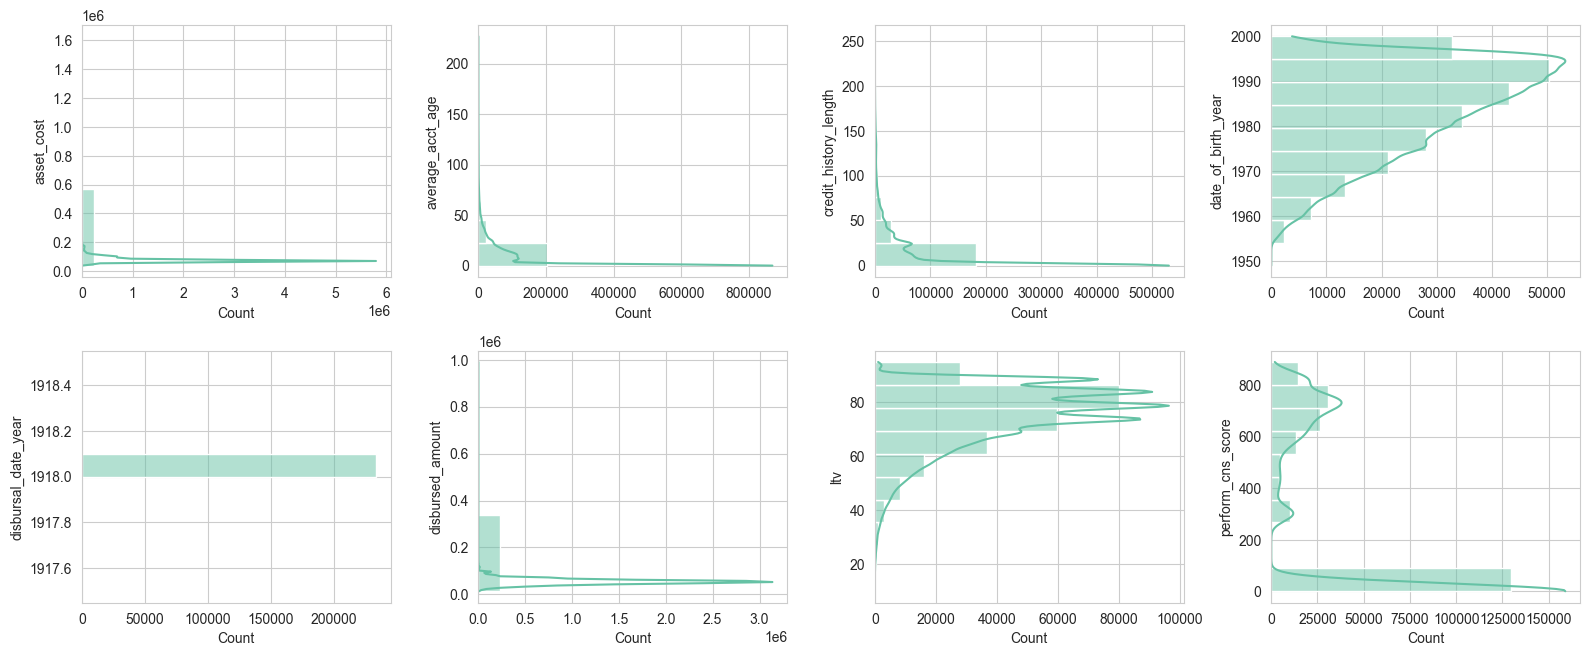

In [46]:
exclude = [
    'unique_id',
    # 'disbursed_amount',
    # 'asset_cost',
    # 'ltv',
    'supplier_id',
    'current_pincode_id',
    'date_of_birth',
    'disbursal_date',
    'employee_code_id',
    'mobileno_avl_flag',
    'aadhar_flag',
    'pan_flag',
    'voterid_flag',
    'driving_flag',
    'passport_flag',
    # 'perform_cns_score',
    'pri_no_of_accts',
    'pri_active_accts',
    'pri_overdue_accts',
    'pri_current_balance',
    'pri_sanctioned_amount',
    'pri_disbursed_amount',
    'sec_no_of_accts',
    'sec_active_accts',
    'sec_overdue_accts',
    'sec_current_balance',
    'sec_sanctioned_amount',
    'sec_disbursed_amount',
    'primary_instal_amt',
    'sec_instal_amt',
    'new_accts_in_last_six_months',
    'delinquent_accts_in_last_six_months',
    # 'average_acct_age',
    # 'credit_history_length',
    'no_of_inquiries',
    'loan_default',
    # 'date_of_birth_year',
    'date_of_birth_yq',
    'date_of_birth_quarter',
    'date_of_birth_ym',
    'date_of_birth_month',
    'date_of_birth_dow',
    # 'disbursal_date_year',
    'disbursal_date_yq',
    'disbursal_date_quarter',
    'disbursal_date_ym',
    'disbursal_date_month',
    'disbursal_date_dow'
]

plt.figure(figsize=(16, 16))
for i, feat in enumerate(scalar_features(dfLoans, exclude=exclude, ascending=True), 1):
    plt.subplot(5, 4, i)
    bins = 3 if feat in ['disbursed_amount', 'asset_cost'] else 10
    sns.histplot(y=dfLoans[feat], bins=bins, kde=True)
    
del exclude, i, feat, bins
plt.tight_layout()

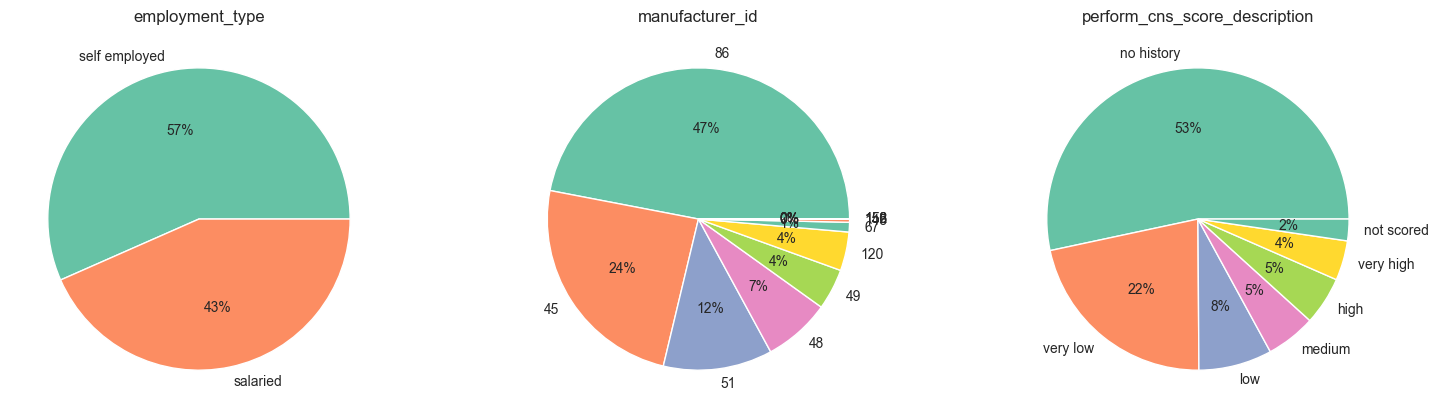

In [47]:
plt.figure(figsize=(20, 20))
for i, feat in enumerate(categorical_features(dfLoans, exclude=['branch_id', 'state_id'], ascending=True), 1):
    plt.subplot(5, 4, i)
    # sns.countplot(y=dfLoans[feat])
    _ = dfLoans[feat].value_counts()
    plt.pie(_, autopct='%1.0f%%', labels=_.index)
    plt.title(_.index.name)

plt.tight_layout()

Observations:

- It's unlikely accidental that a majority of customers are self-employed, indicating business decisions that both exclude other incomes, and guide the product (loans) offered
- Also unlikely accidental that 55% of customers either `weren't scored` or had `no credit history` -- together the with `low` and `very low` credit scores -- illustrates deliberate business bias that may impact defaults
- 71% of all loans relate to manufacturers 86 and 45, indicating there either is a bias or an opportunity for margin / revenue optimisation (through perhaps a negotiated relationship eg cross-selling)

#### Analysis of target feature: `loan_default`

In [48]:
dfLoansYN = (dfLoan
    .assign(loan_default = lambda _: np.where(_.loan_default == 1, 'Yes', 'No'))
)
dfLoansYN.loan_default


0          No
1         Yes
2          No
3         Yes
4         Yes
         ... 
233149     No
233150     No
233151     No
233152     No
233153     No
Name: loan_default, Length: 233154, dtype: object

<Axes: title={'center': 'loan_default'}>

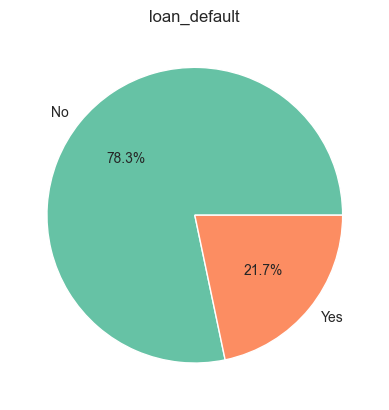

In [49]:
(dfLoansYN
    .loan_default
    .value_counts()
    .plot.pie(title='loan_default', ylabel="", autopct='%1.1f%%')
)

Observations:

- ~22% -- or 1 in 5 -- loans suffer default.  This could be the result of above's insights, but without comparison one can't infer how typical this outcome may be for the business model / industry / geography / (loans) product offering

### Bivariate Analysis

Text(0.5, 1.0, 'Disbursed Amount vs Asset Cost')

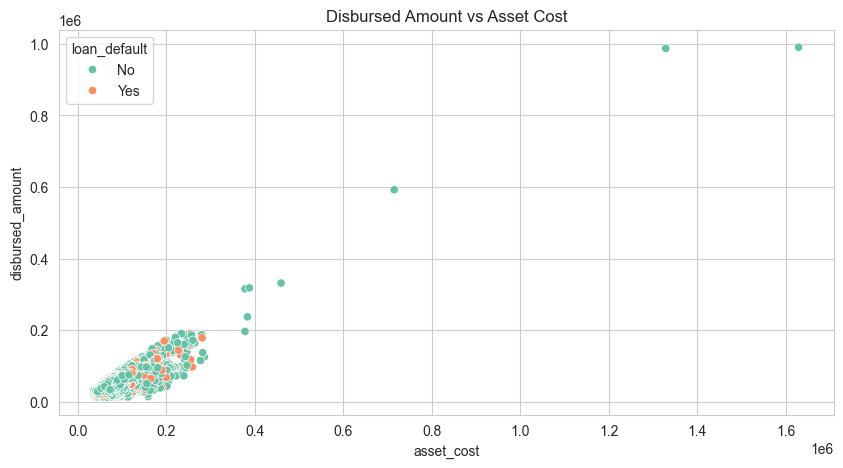

In [50]:
plt.figure(figsize=(10,5))
sns.scatterplot(dfLoansYN, x=dfLoansYN.asset_cost, y=dfLoansYN.disbursed_amount, hue=dfLoansYN.loan_default)
plt.title('Disbursed Amount vs Asset Cost')

Observations:

- The vast majority of loans are for the bottom 20% of asset values (collateral / purchased asset)
- The vast majority of loans are for the bottom 20% of disbursed amounts

Text(0.5, 1.0, 'Disbursed Amount vs Loan-to-Value (LTV)')

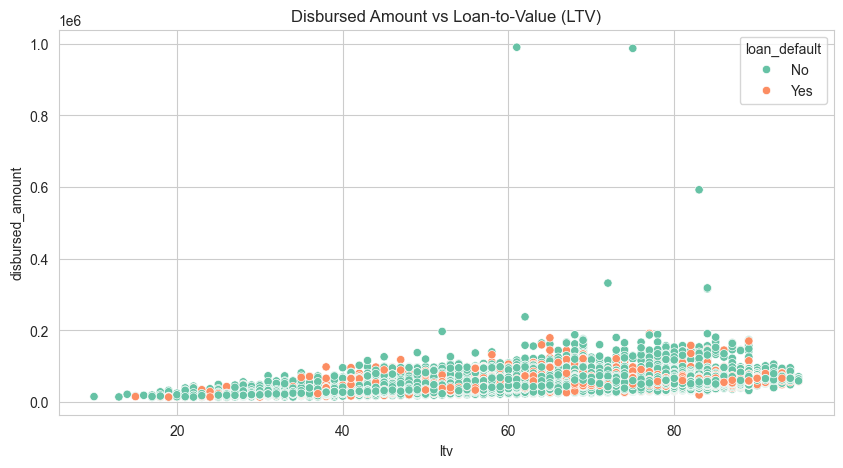

In [51]:
plt.figure(figsize=(10,5))
sns.scatterplot(dfLoansYN, x=dfLoansYN.ltv, y=dfLoansYN.disbursed_amount, hue=dfLoansYN.loan_default)
plt.title('Disbursed Amount vs Loan-to-Value (LTV)')

Observations:

- Loan defaults are largely equally spread throughout the Loan-to-Value (LTV) range, and
- Continuing above's obervations: its rather the outlier loans -- high disbursals or high asset values -- that present the least risk of default 

<Axes: title={'center': 'Loan Defaults by Scoring'}, xlabel='perform_cns_score_description'>

<Figure size 1000x500 with 0 Axes>

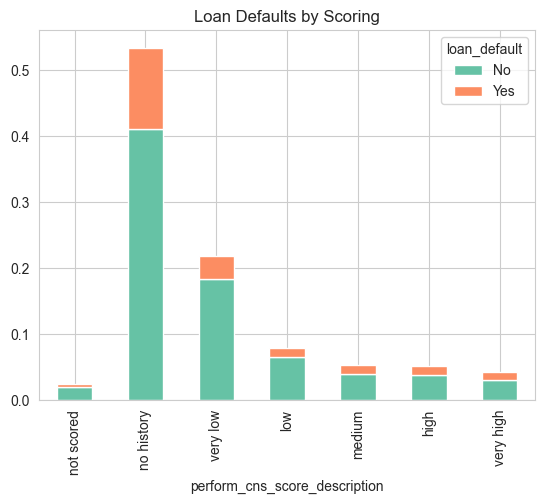

In [52]:
plt.figure(figsize=(10,5))
(pd.crosstab(dfLoansYN.perform_cns_score_description, dfLoansYN.loan_default, normalize=True)
    .plot
    .bar(stacked=True, title='Loan Defaults by Scoring')
)

Observations:

- While this business readily loans to customers with no credit history (~53% of all customers), the proportion of loan defaults is largely consistent throughout the credit history range.

<Axes: title={'center': 'Loan Defaults by State'}, xlabel='state_id'>

<Figure size 1500x500 with 0 Axes>

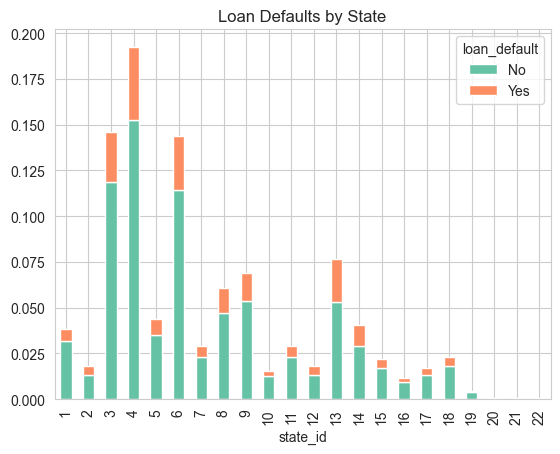

In [53]:
plt.figure(figsize=(15,5))
(pd.crosstab(dfLoansYN.state_id, dfLoansYN.loan_default, normalize=True)
    .plot
    .bar(stacked=True, title='Loan Defaults by State')
)

Observations:

- States 3, 4, and 6, together make the majority of loan issues
- With exception of States 19 - 22 who write negligible loans where none have defaulted, the rate of default is largely consistent across all States

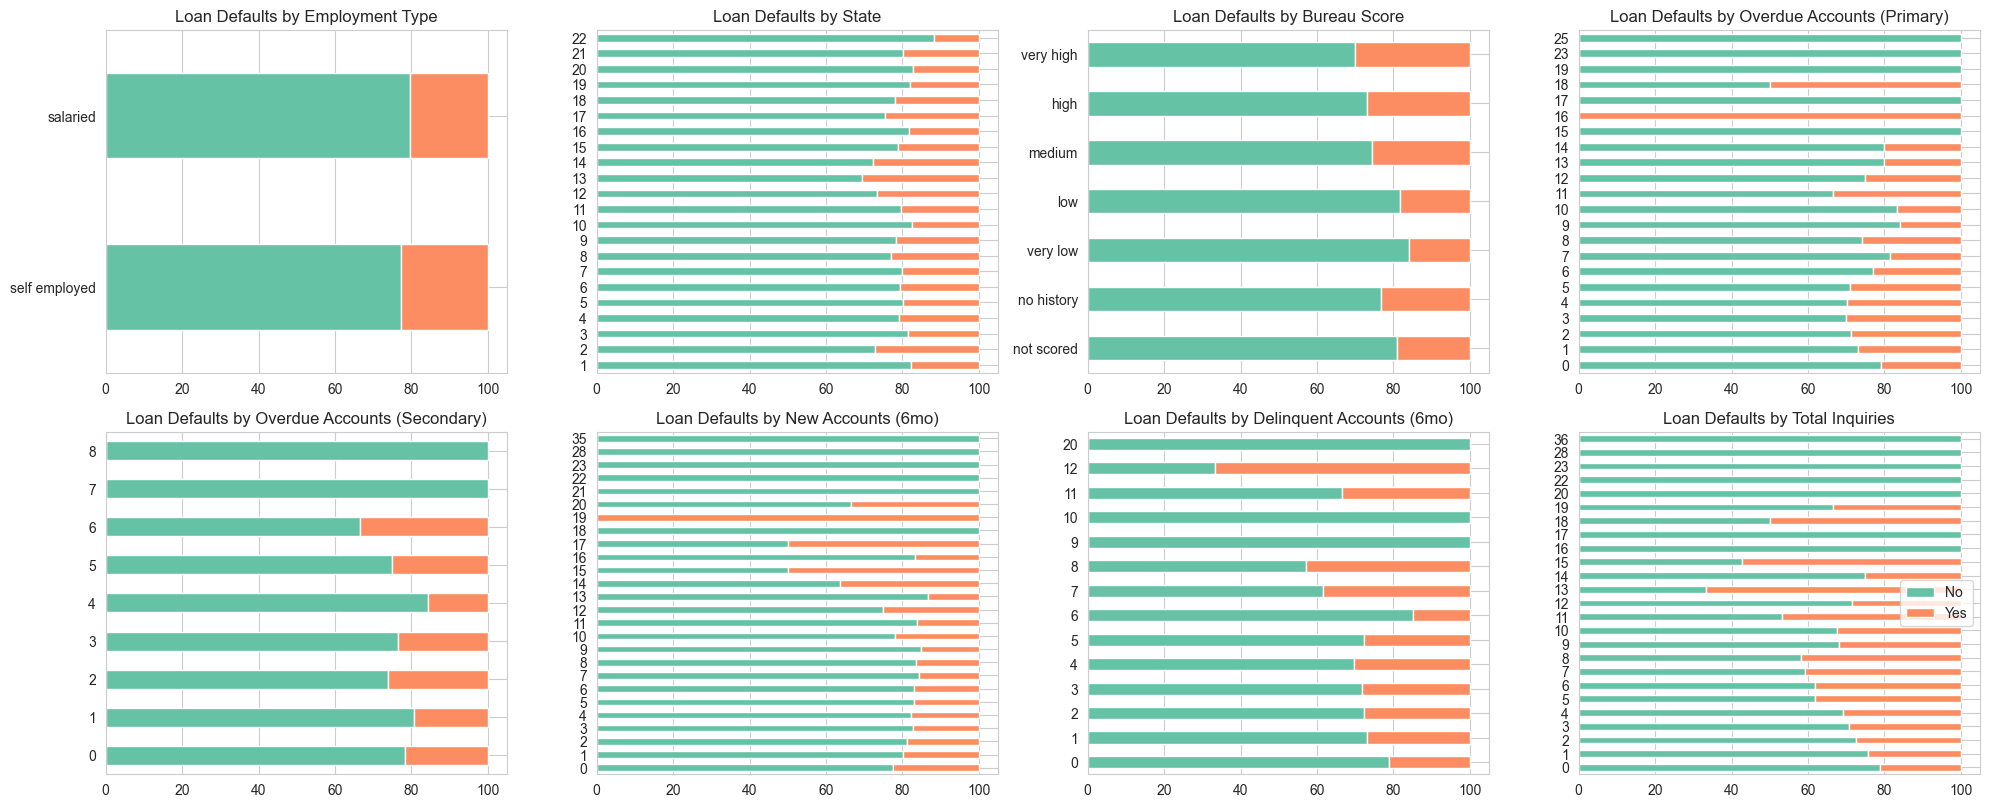

In [54]:
barh_specs = [
    #group                                  target          both   title
    ('employment_type',                     target_feature, False, 'Loan Defaults by Employment Type'),
    ('state_id',                            target_feature, False, 'Loan Defaults by State'),
    # ('manufacturer_id',                     target_feature, False, 'Loan Defaults by Manufacturer'),
    ('perform_cns_score_description',       target_feature, False, 'Loan Defaults by Bureau Score'),
    ('pri_overdue_accts',                   target_feature, False, 'Loan Defaults by Overdue Accounts (Primary)'),
    ('sec_overdue_accts',                   target_feature, False, 'Loan Defaults by Overdue Accounts (Secondary)'),
    ('new_accts_in_last_six_months',        target_feature, False, 'Loan Defaults by New Accounts (6mo)'),
    ('delinquent_accts_in_last_six_months', target_feature, False, 'Loan Defaults by Delinquent Accounts (6mo)'),
    ('no_of_inquiries',                     target_feature, False, 'Loan Defaults by Total Inquiries'),
    # ('date_of_birth_quarter',               target_feature, False, 'Loan Defaults by Birth Quarter'),
    # ('date_of_birth_month',                 target_feature, False, 'Loan Defaults by Birth Month'),
    # ('date_of_birth_dow',                   target_feature, False, 'Loan Defaults by Birth Day in Week'),
    # ('disbursal_date_quarter',              target_feature, False, 'Loan Defaults by Disbursement Quarter'),
    # ('disbursal_date_month',                target_feature, False, 'Loan Defaults by Disbursement Month'),
    # ('disbursal_date_dow',                  target_feature, False, 'Loan Defaults by Disbursement Day in Week'),
]


plt.figure(figsize=(20, 20))
for i, (group, target, both, title) in enumerate(barh_specs, 1):
    dfLoansYN.groupby(group, observed=True)[target].value_counts(normalize=True).unstack() \
        .rename(columns={0: 'No', 1: 'Yes'}, index={0: 'No', 1: 'Yes'} if both else None) \
        .apply(lambda v: v * 100) \
        .plot(kind='barh', stacked=True, title=title, ylabel="", ax=plt.subplot(5, 4, i), legend=False)

del i, group, target, both, title, barh_specs
plt.legend()
plt.tight_layout()

### Mulrivariate Analysis

<Axes: >

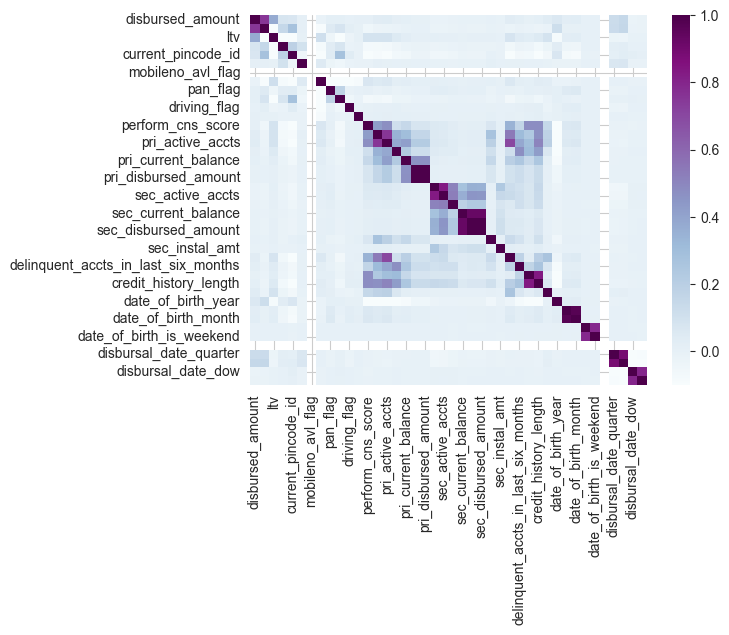

In [55]:
sns.heatmap(
    dfLoansYN
        .drop('unique_id', axis='columns')
        .corr(numeric_only=True), 
    cmap="BuPu", 
    robust=True)

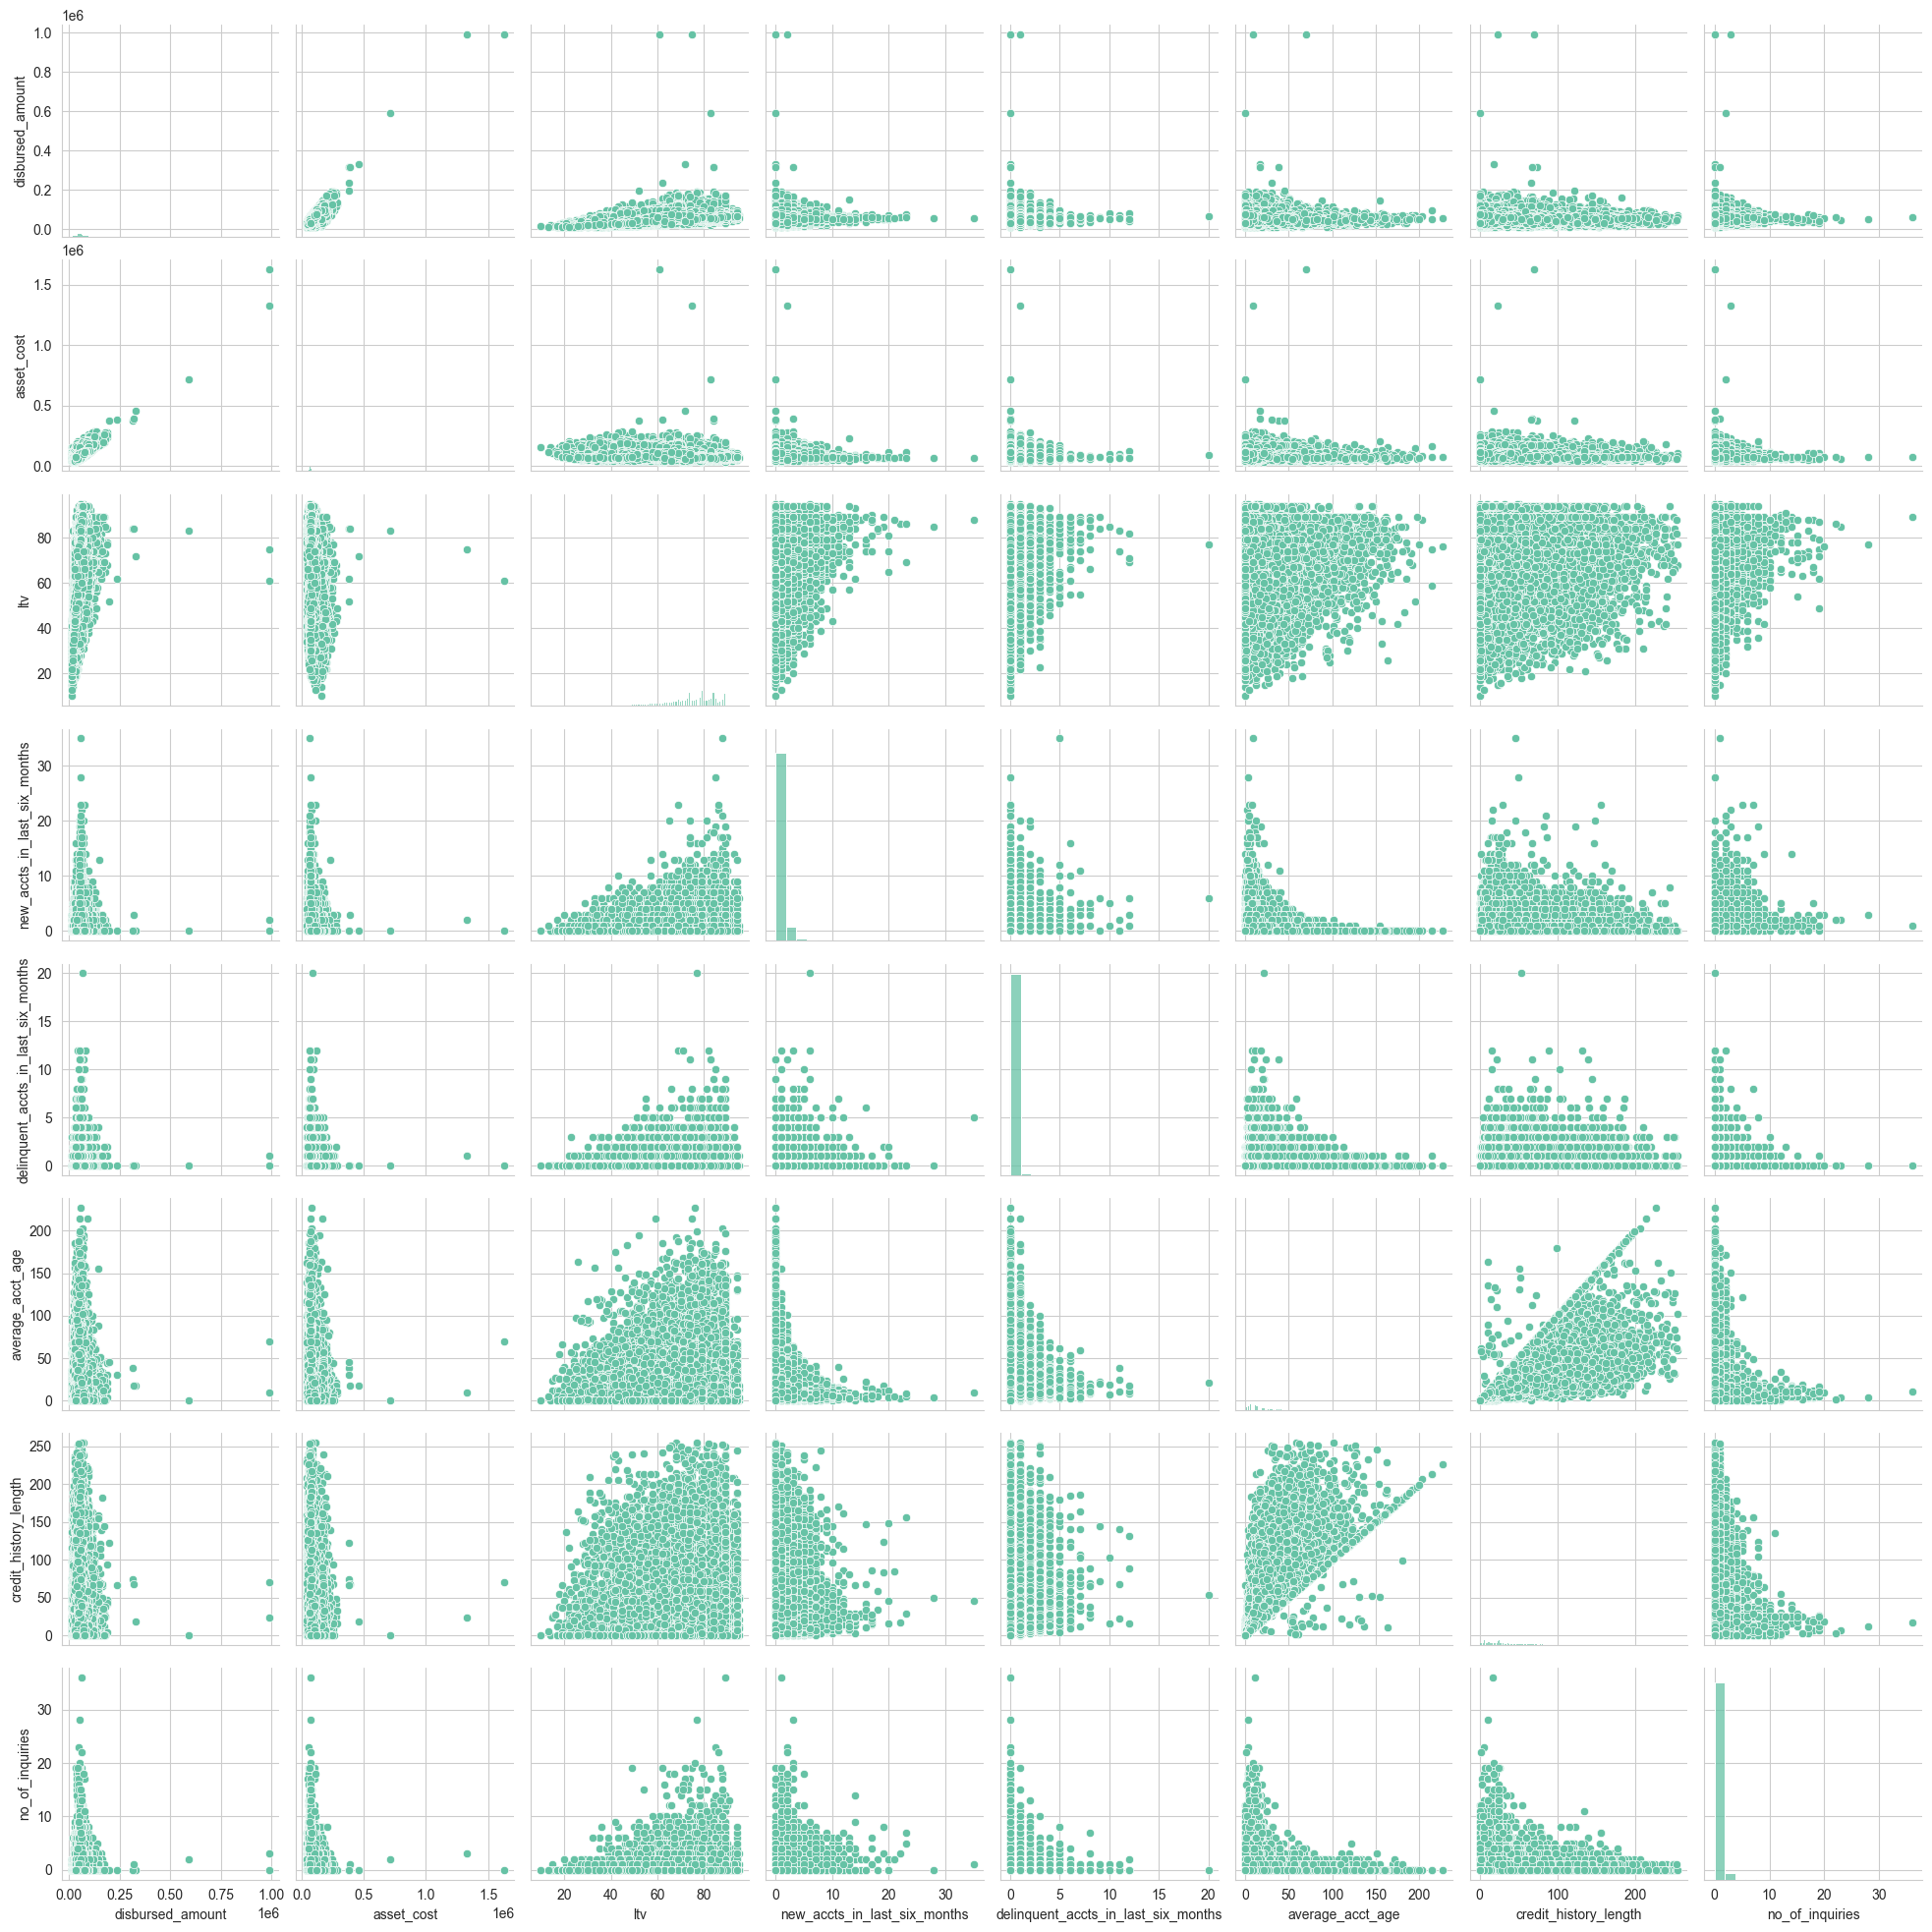

In [56]:
sns.pairplot(dfLoansYN[[
    'disbursed_amount',
    'asset_cost',
    'ltv',
    'new_accts_in_last_six_months',
    'delinquent_accts_in_last_six_months',
    'average_acct_age',
    'credit_history_length',
    'no_of_inquiries',
]])

In [57]:
del dfLoansYN

## Modelling

In [58]:
features_not_compatible_with_modelling = [
    'date_of_birth',    
    'date_of_birth_yq', 
    'date_of_birth_ym', 
    'disbursal_date',   
    'disbursal_date_yq',
    'disbursal_date_ym',    
]

features_to_transform = {
    'employment_type'               : lambda _: top_n_encoder(_, 2),
    'perform_cns_score_description' : lambda _: top_n_encoder(_),
}

In [59]:
# tuning results
best_tuning = {}

# tuning parameter ranges
C_range = [0.01, 0.1, 0.5, 1.0]
max_depth_range = [5, 8, 11, 13]
weights_range = ['balanced', { 0: 0.5, 1: 1.0 }, { 0: 0.5, 1: 2.0 }, { 0: 0.5, 1: 3.0 }]
estimators_range = range(10, 101, 15)
boost_eta_range = [0.03, 0.25, 0.3667]

### Target feature imbalance

In [60]:
print(f'{target_feature} == 1:  {dfLoans[target_feature].mean():.1%}')

loan_default == 1:  21.7%

### Feature Selection

In [109]:
dfLoans_feature_selection = (
    dfLoans
        .assign(
            branch_id                     = lambda _: _.branch_id.cat.codes,
            manufacturer_id               = lambda _: _.manufacturer_id.cat.codes,
            state_id                      = lambda _: _.state_id.cat.codes,
        )
        .drop(features_not_compatible_with_modelling, axis='columns')
        .pipe(  
            preprocessing, 
            features_to_transform         = features_to_transform | {
                'disbursed_amount'        : lambda _: series_scaler(_),
                'asset_cost'              : lambda _: series_scaler(_),
                'pri_current_balance'     : lambda _: series_scaler(_),
                'pri_sanctioned_amount'   : lambda _: series_scaler(_),
                'pri_disbursed_amount'    : lambda _: series_scaler(_),
                'sec_current_balance'     : lambda _: series_scaler(_),
                'sec_sanctioned_amount'   : lambda _: series_scaler(_),
                'sec_disbursed_amount'    : lambda _: series_scaler(_),
            }
        )
)

dfLoans_feature_selection.head().T

top_n_encoder: 96.71% of employment_type values: ['self employed', 'salaried']

top_n_encoder: 100.00% of perform_cns_score_description values: ['no history', 'very low', 'low', 'medium', 'high',
'very high', 'not scored']

unique_id,420825,537409,417566,624493,539055
ltv,89,73,89,88,88
branch_id,30,30,30,30,30
supplier_id,22807,22807,22807,22807,22807
manufacturer_id,0,0,0,0,0
current_pincode_id,1441,1502,1497,1501,1495
state_id,5,5,5,5,5
employee_code_id,1998,1998,1998,1998,1998
mobileno_avl_flag,1,1,1,1,1
aadhar_flag,1,1,1,1,1
pan_flag,0,0,0,0,0


In [110]:
%%time

df_train, df_val, _, _ = validation_testing_training_full_split(dfLoans_feature_selection, 
                                                                seed=seed, 
                                                                shuffle=True, 
                                                                stratify=target_feature)

df_train, y_train = y_split(df_train, yColumn=target_feature)
df_val,   y_val   = y_split(df_val,   yColumn=target_feature)

CPU times: total: 578 ms
Wall time: 919 ms


In [111]:
%%time

model = DecisionTreeClassifier(max_depth=max(max_depth_range), random_state=seed)
model.fit(df_train, y_train)

CPU times: total: 3.7 s
Wall time: 6.2 s


DecisionTreeClassifier(max_depth=13, random_state=42)

In [64]:
print(f'  training data score: { model.score(df_train, y_train):.2%}')
print(f'validation data score: { model.score(df_val,   y_val  ):.2%}')

training data score: 81.27%

validation data score: 76.16%

In [112]:
f1_all_features = round( f1_score(y_val, model.predict(df_val), average='weighted') , 3)
f1_all_features

0.703

#### K-best features method - Filter

In [66]:
%%time

scores = []

for k in tqdm( range(1, len(df_train.columns)) ):
    selector = SelectKBest(mutual_info_classif, k=k)
    
    selected_train = selector.fit_transform(df_train, y_train)
    selected_val   = selector.transform(df_val)
    
    selected_features_mask = selector.get_support()
    
    model.fit(selected_train, y_train)
    selected_pred = model.predict(selected_val)
    
    scores.append( (
        k, 
        round(      f1_score(y_val, selected_pred, average='weighted'), 3),
        round( roc_auc_score(y_val, selected_pred, average='weighted'), 3),
        list(df_train.columns[  selected_features_mask ]),
        list(df_train.columns[ ~selected_features_mask ])
    ) )

df_kbest_feature_selection = pd.DataFrame(scores, columns=['k', 'f1', 'roc_auc', 'selected_features', 'dropped_features'])

del k, selected_pred, selected_train, selected_val, selected_features_mask, selector, scores

  0%|          | 0/53 [00:00<?, ?it/s]

CPU times: total: 1h 2min 15s
Wall time: 1h 3min 38s


In [67]:
(df_kbest_feature_selection
    [df_kbest_feature_selection.f1 > f1_all_features]
    .sort_values(by=['f1', 'roc_auc'], ascending=[False, False])
)

,k,f1,roc_auc,selected_features,dropped_features
51,52,0.704,0.518,"[ltv, branch_id, supplier_id, manufacturer_id,...","[driving_flag, pri_no_of_accts]"
38,39,0.704,0.517,"[ltv, branch_id, supplier_id, manufacturer_id,...","[pan_flag, driving_flag, passport_flag, pri_ac..."
41,42,0.704,0.517,"[ltv, branch_id, supplier_id, manufacturer_id,...","[pan_flag, voterid_flag, driving_flag, passpor..."


In [68]:
(df_kbest_feature_selection
    [df_kbest_feature_selection.f1 > f1_all_features]
    .sort_values(by=['f1', 'roc_auc', 'k'], ascending=[False, False, True])
).iloc[0].dropped_features

['driving_flag', 'pri_no_of_accts']

In [69]:
# fig, ax = plt.subplots()

# x = np.arange(1, len(df_train.columns))
# y = df_kbest_feature_selection.f1

# ax.bar(x, y)
# ax.set_xticks(x)
# ax.set_xticklabels(x)
# ax.set_xlabel('# selected features using Mutual Information')
# ax.set_ylim(0, 1.2)
# ax.set_ylabel('F1 weighted average')

# for i, v in enumerate(y.values):
#     plt.text(x=i+1, y=v+0.05, s=str(v), ha='center')

# plt.tight_layout()

#### Recursive feature elimination (RFE) method - Wrapper

In [70]:
%%time

scores = []

for k in tqdm( range(1, len(df_train.columns)) ):
    selector = RFE(estimator=model, n_features_to_select=k)
    
    selected_train = selector.fit_transform(df_train, y_train)
    selected_val   = selector.transform(df_val)
    
    selected_features_mask = selector.get_support()
    
    model.fit(selected_train, y_train)
    selected_pred = model.predict(selected_val)
    
    scores.append( (
        k, 
        round(      f1_score(y_val, selected_pred, average='weighted'), 3),
        round( roc_auc_score(y_val, selected_pred, average='weighted'), 3),
        list(df_train.columns[  selected_features_mask ]),
        list(df_train.columns[ ~selected_features_mask ])
    ) )

df_rfe_feature_selection = pd.DataFrame(scores, columns=['k', 'f1', 'roc_auc', 'selected_features', 'dropped_features'])

del k, selected_pred, selected_train, selected_val, selected_features_mask, selector, scores

  0%|          | 0/53 [00:00<?, ?it/s]

CPU times: total: 59min 48s
Wall time: 1h 19s


In [71]:
(df_rfe_feature_selection
    [df_rfe_feature_selection.f1 > f1_all_features]
    .sort_values(by=['f1', 'roc_auc'], ascending=[False, False])
)

,k,f1,roc_auc,selected_features,dropped_features
27,28,0.704,0.517,"[ltv, branch_id, supplier_id, manufacturer_id,...","[mobileno_avl_flag, aadhar_flag, pan_flag, vot..."
43,44,0.704,0.517,"[ltv, branch_id, supplier_id, manufacturer_id,...","[mobileno_avl_flag, passport_flag, date_of_bir..."
46,47,0.704,0.517,"[ltv, branch_id, supplier_id, manufacturer_id,...","[mobileno_avl_flag, passport_flag, disbursal_d..."


In [72]:
(df_rfe_feature_selection
    [df_rfe_feature_selection.f1 > f1_all_features]
    .sort_values(by=['f1', 'roc_auc'], ascending=[False, False])
).iloc[0].dropped_features


[
    'mobileno_avl_flag',
    'aadhar_flag',
    'pan_flag',
    'voterid_flag',
    'driving_flag',
    'passport_flag',
    'pri_active_accts',
    'sec_no_of_accts',
    'sec_active_accts',
    'sec_overdue_accts',
    'sec_instal_amt',
    'date_of_birth_quarter',
    'date_of_birth_is_weekend',
    'disbursal_date_year',
    'disbursal_date_is_weekend',
    'employment_type=salaried',
    'perform_cns_score_description=no history',
    'perform_cns_score_description=very low',
    'perform_cns_score_description=low',
    'perform_cns_score_description=medium',
    'perform_cns_score_description=high',
    'perform_cns_score_description=very high',
    'perform_cns_score_description=not scored',
    'sec_current_balance',
    'sec_sanctioned_amount',
    'sec_disbursed_amount'
]

Observations:

 - Both methods -- KBest and RFE -- return similar results with largely overlapping feature selection
 - However, as the RFE method has a smidge better ROC_AUC score, and it's feature selection resembles features found 'insignificant' during EDA, it's the preferred result
 - Some calculated `dropped_features` (see above, e.g. `employment_type`) will be ignored:

#### Features calculated as insignificant

In [113]:
features_calculated_as_insignificant = [
    'mobileno_avl_flag',
    'aadhar_flag',
    'pan_flag',
    'voterid_flag',
    'driving_flag',
    'passport_flag',
    # 'pri_active_accts',
    'sec_no_of_accts',
    'sec_active_accts',
    'sec_overdue_accts',
    'sec_instal_amt',
    'date_of_birth_quarter',
    'date_of_birth_is_weekend',
    'disbursal_date_year',
    'disbursal_date_is_weekend',
    'sec_current_balance',
    'sec_sanctioned_amount',
    'sec_disbursed_amount'
]

# [
#     'pan_flag',
#     'passport_flag',
#     'sec_no_of_accts',
#     'sec_active_accts',
#     'sec_overdue_accts',
#     'primary_instal_amt',
#     'new_accts_in_last_six_months',
#     'delinquent_accts_in_last_six_months',
#     'credit_history_length',
#     'no_of_inquiries',
#     'perform_cns_score_description=medium',
#     'perform_cns_score_description=high',
#     'perform_cns_score_description=not scored',
#     'sec_sanctioned_amount',
#     'sec_disbursed_amount'
# ]

In [104]:
del df_kbest_feature_selection, df_rfe_feature_selection

##### Impact on modelling

In [114]:
df_train = df_train .drop(features_calculated_as_insignificant, axis='columns')
df_val   = df_val   .drop(features_calculated_as_insignificant, axis='columns')

In [115]:
%%time

model.fit(df_train, y_train)

CPU times: total: 2.55 s
Wall time: 3.17 s


DecisionTreeClassifier(max_depth=13, random_state=42)

In [116]:
%%time

print(f'  training data score: { model.score(df_train, y_train):.2%}')
print(f'validation data score: { model.score(df_val  , y_val  ):.2%}')

training data score: 81.26%

validation data score: 76.17%

CPU times: total: 125 ms
Wall time: 251 ms


#####  What are the significant features?

Text(0.5, 1.0, 'Feature significance AFTER feature selection')

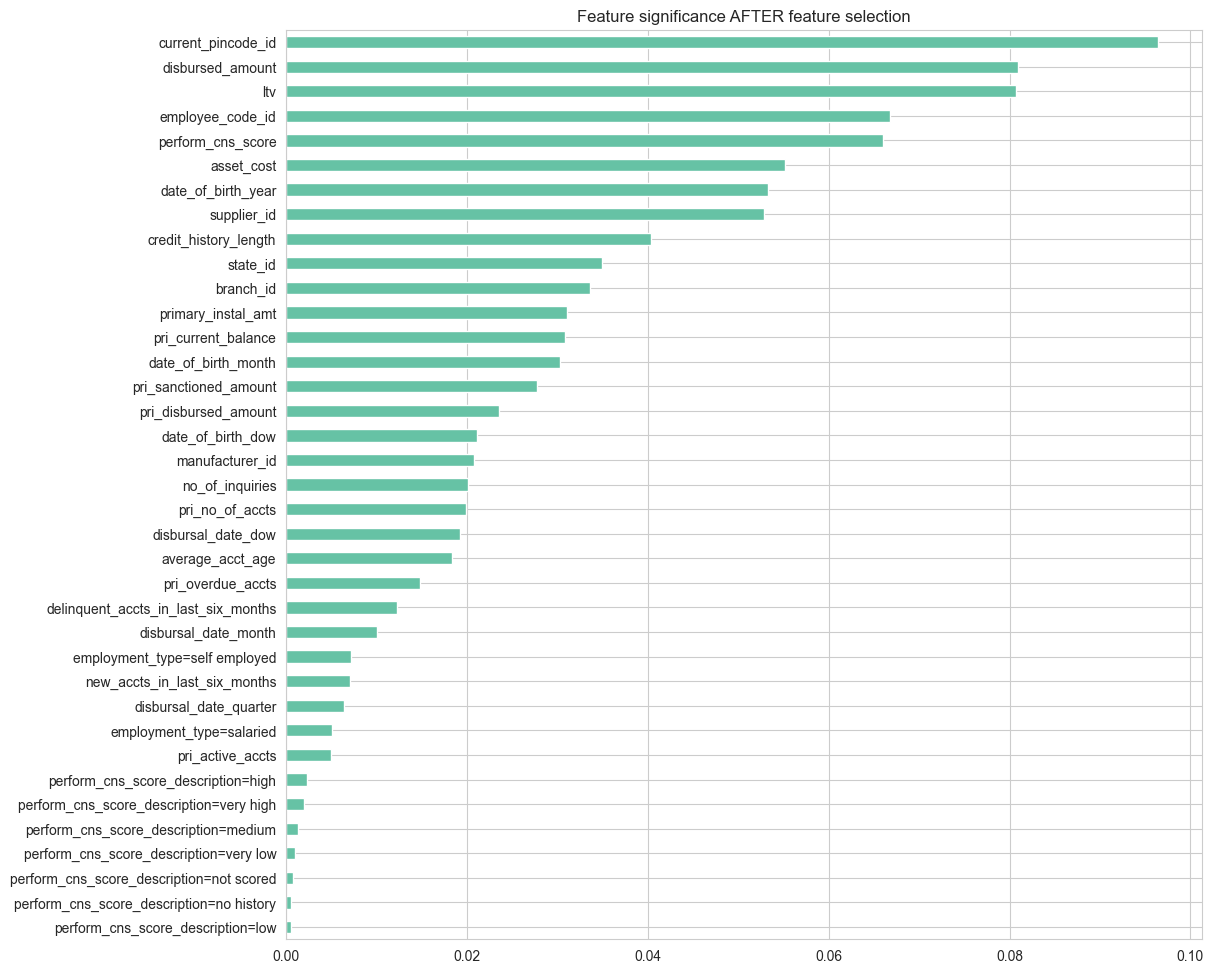

In [117]:
plt.subplots(1, figsize=(30*cm, 30*cm ))

(pd.Series(model.feature_importances_, index=df_val.columns)
    .sort_values()
    .plot.barh()
).set_title('Feature significance AFTER feature selection')

In [78]:
# print( export_text(
#     decision_tree   = model,
#     feature_names   = df_val.drop(features_calculated_as_insignificant, axis=1).columns,
#     # show_weights    = True,
# ))

### Preprocess `dfLoans` for modelling

In [79]:
del df_train, df_val, y_train, y_val, model, dfLoans_feature_selection
# del dv, preds_val, df_kbest_feature_selection, df_rfe_feature_selection

In [80]:
# f1_all_features = 0.698
f1_all_features

0.703

In [81]:
features_not_compatible_with_modelling


[
    'date_of_birth',
    'date_of_birth_yq',
    'date_of_birth_ym',
    'disbursal_date',
    'disbursal_date_yq',
    'disbursal_date_ym'
]

In [82]:
features_calculated_as_insignificant


[
    'mobileno_avl_flag',
    'aadhar_flag',
    'pan_flag',
    'voterid_flag',
    'driving_flag',
    'passport_flag',
    'sec_no_of_accts',
    'sec_active_accts',
    'sec_overdue_accts',
    'sec_instal_amt',
    'date_of_birth_quarter',
    'date_of_birth_is_weekend',
    'disbursal_date_year',
    'disbursal_date_is_weekend',
    'sec_current_balance',
    'sec_sanctioned_amount',
    'sec_disbursed_amount'
]

In [83]:
dfLoans_processed = (
    dfLoans
    .pipe(shape_of)
    .pipe(memory_consumption_of)
    
    .drop(features_not_compatible_with_modelling, axis='columns')
    .pipe(preprocessing, features_to_transform)
    .drop(features_calculated_as_insignificant, axis='columns')
    
    .pipe(shape_of)
    .pipe(memory_consumption_of)
)

shape = (233154, 55)

memory consumption = 43.59 MB

top_n_encoder: 96.71% of employment_type values: ['self employed', 'salaried']

top_n_encoder: 100.00% of perform_cns_score_description values: ['no history', 'very low', 'low', 'medium', 'high',
'very high', 'not scored']

shape = (233154, 38)

memory consumption = 22.46 MB

In [84]:
(dfLoans_processed
    .describe(include='all')
    .T
)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
disbursed_amount,233154.0,NaN,NaN,NaN,54356.996094,1.297131e+04,13320.0,47145.0,53803.0,60413.00,9.905720e+05
asset_cost,233154.0,NaN,NaN,NaN,75865.070312,1.894478e+04,37000.0,65717.0,70946.0,79201.75,1.628992e+06
ltv,233154.0,NaN,NaN,NaN,74.228128,1.144209e+01,10.0,68.0,76.0,83.00,9.500000e+01
branch_id,233154.0,82.0,2.0,13138.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
supplier_id,233154.0,NaN,NaN,NaN,19638.635035,3.491950e+03,10524.0,16535.0,20333.0,23000.00,2.480300e+04
manufacturer_id,233154.0,11.0,86.0,109534.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
current_pincode_id,233154.0,NaN,NaN,NaN,3396.880247,2.238148e+03,1.0,1511.0,2970.0,5677.00,7.345000e+03
state_id,233154.0,22.0,4.0,44870.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
employee_code_id,233154.0,NaN,NaN,NaN,1549.477148,9.752613e+02,1.0,713.0,1451.0,2362.00,3.795000e+03
perform_cns_score,233154.0,NaN,NaN,NaN,289.462994,3.383748e+02,0.0,0.0,0.0,678.00,8.900000e+02


### Split the data

In [85]:
df_train, df_val, df_full, df_test = validation_testing_training_full_split(dfLoans_processed, seed=seed, shuffle=True, stratify=target_feature)

nTrain = len(df_train)
nVal = len(df_val)
nTest = len(df_test)
nFull = len(df_full)
nTotal = len(dfLoans_processed)

print(f'df_train = {nTrain/nTotal:.1%}, df_val = {nVal/nTotal:.1%}, df_test = {nTest/nTotal:.1%}, df_full = {nFull/nTotal:.1%}')

del nTrain, nVal, nTest, nFull, nTotal

df_train = 60.0%, df_val = 20.0%, df_test = 20.0%, df_full = 80.0%

In [86]:
df_val,   y_val   = y_split(df_val,   yColumn=target_feature)
df_test,  y_test  = y_split(df_test,  yColumn=target_feature)
df_train, y_train = y_split(df_train, yColumn=target_feature)
df_full,  y_full  = y_split(df_full,  yColumn=target_feature)

assert df_val.shape[1] == df_test.shape[1] and df_test.shape[1] == df_train.shape[1] and df_train.shape[1] == df_full.shape[1]
assert len(y_val) == df_val.shape[0] and len(y_test) == df_test.shape[0] and len(y_train) == df_train.shape[0] and len(y_full) == df_full.shape[0]

### Baseline Model: Decision Tree (as `y_*` is categorical)

In [87]:
%%time

model = DecisionTreeClassifier(max_depth=max(max_depth_range), random_state=seed)  # Without `max_depth` it will over-fit; not useful for hyperparameter tuning comparison
model.fit(df_train, y_train)

CPU times: total: 2.52 s
Wall time: 2.65 s


DecisionTreeClassifier(max_depth=13, random_state=42)

In [88]:
print(f'  training data score: { model.score(df_train, y_train):.2%}')
print(f'validation data score: { model.score(df_val,   y_val  ):.2%}')

training data score: 81.27%

validation data score: 76.07%

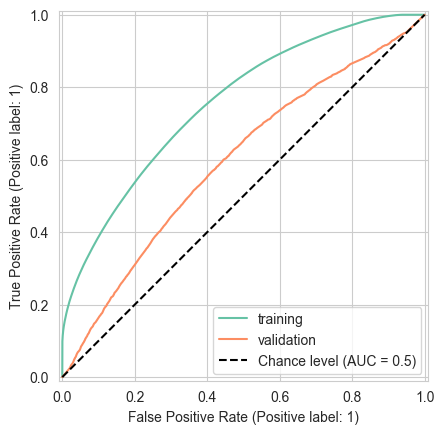

In [89]:
fig, ax = plt.subplots()
RocCurveDisplay.from_estimator(model, df_train, y_train, ax=ax, label='training')
RocCurveDisplay.from_estimator(model, df_val,   y_val,   ax=ax, label='validation', plot_chance_level=True)

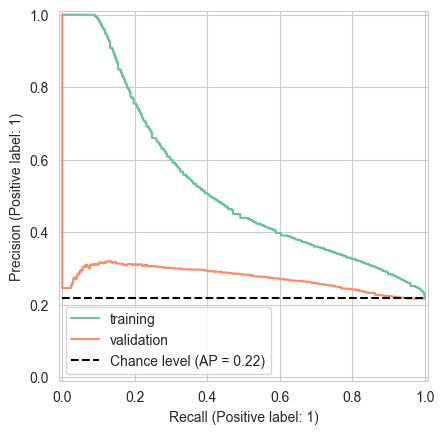

In [90]:
fig, ax = plt.subplots()
PrecisionRecallDisplay.from_estimator(model, df_train, y_train, ax=ax, label='training')
PrecisionRecallDisplay.from_estimator(model, df_val,   y_val,   ax=ax, label='validation', plot_chance_level=True)

In [91]:
best_result = {
    'max_depth':    max(max_depth_range),
    'f1':           round(      f1_score(y_val, model.predict(df_val), average='weighted'), 3),
    'roc_auc':      round( roc_auc_score(y_val, model.predict(df_val), average='weighted'), 3),
}

best_result |= {
    'model': DecisionTreeClassifier(
        max_depth   = int( best_result['max_depth'] ), 
        random_state= seed),
    'vectorizer': None,
    'fitter': lambda model, vectorizer, train, y_train, test, y_test: 
        model.fit(train, y_train),
    'predicter': lambda model, vectorizer, test: 
        model.predict(test)
}

best_tuning |= { 'baseline': best_result }

print(f'{ best_tuning = }')

best_tuning = {'baseline': {'max_depth': 13, 'f1': 0.703, 'roc_auc': 0.516, 'model': 
DecisionTreeClassifier(max_depth=13, random_state=42), 'vectorizer': None, 'fitter': <function <lambda> at 
0x000001A2016A7060>, 'predicter': <function <lambda> at 0x000001A2016A71A0>}}

### Decision Tree model hyperparameter tuning

In [92]:
%%time

scores = []

for criteria in ['gini', 'entropy', 'log_loss']:
    for weights in weights_range:
        for depth in tqdm( max_depth_range, desc=f'{criteria=}, {weights=}'):
            model = DecisionTreeClassifier(criterion=criteria, class_weight=weights, max_depth=depth, random_state=seed, min_samples_leaf=10)
            
            model.fit(df_train, y_train)
            y_pred = model.predict(df_val)
            
            scores.append( (
                criteria,
                weights,
                depth,
                round(      f1_score(y_val, y_pred, average='weighted'), 3),
                round( roc_auc_score(y_val, y_pred, average='weighted'), 3)
            ) )
            
(pd.DataFrame(scores, columns=['criterion', 'class_weight', 'max_depth', 'f1', 'roc_auc'])
    .query(f'f1 >= { f1_all_features }')
    .sort_values(by=['f1', 'roc_auc'], ascending=[False, False])
)

criteria='gini', weights='balanced':   0%|          | 0/4 [00:00<?, ?it/s]

criteria='gini', weights={0: 0.5, 1: 1.0}:   0%|          | 0/4 [00:00<?, ?it/s]

criteria='gini', weights={0: 0.5, 1: 2.0}:   0%|          | 0/4 [00:00<?, ?it/s]

criteria='gini', weights={0: 0.5, 1: 3.0}:   0%|          | 0/4 [00:00<?, ?it/s]

criteria='entropy', weights='balanced':   0%|          | 0/4 [00:00<?, ?it/s]

...

criteria='log_loss', weights={0: 0.5, 1: 1.0}:   0%|          | 0/4 [00:00<?, ?it/s]

criteria='log_loss', weights={0: 0.5, 1: 2.0}:   0%|          | 0/4 [00:00<?, ?it/s]

criteria='log_loss', weights={0: 0.5, 1: 3.0}:   0%|          | 0/4 [00:00<?, ?it/s]

CPU times: total: 1min 40s
Wall time: 1min 44s


,criterion,class_weight,max_depth,f1,roc_auc
21,entropy,"{0: 0.5, 1: 1.0}",8,0.716,0.539
37,log_loss,"{0: 0.5, 1: 1.0}",8,0.716,0.539
5,gini,"{0: 0.5, 1: 1.0}",8,0.715,0.539
22,entropy,"{0: 0.5, 1: 1.0}",11,0.711,0.548
38,log_loss,"{0: 0.5, 1: 1.0}",11,0.711,0.548
6,gini,"{0: 0.5, 1: 1.0}",11,0.709,0.546
4,gini,"{0: 0.5, 1: 1.0}",5,0.709,0.524
20,entropy,"{0: 0.5, 1: 1.0}",5,0.709,0.524
36,log_loss,"{0: 0.5, 1: 1.0}",5,0.709,0.524
23,entropy,"{0: 0.5, 1: 1.0}",13,0.706,0.542


In [93]:
best_result = (pd.DataFrame(scores, columns=['criterion', 'class_weight', 'max_depth', 'f1', 'roc_auc'])
    .sort_values(by=['f1', 'roc_auc'], ascending=[False, False])
    .iloc[0]
    .to_dict()
) 

best_result |= {
    'model': DecisionTreeClassifier(
        criterion       = best_result['criterion'],
        class_weight    = best_result['class_weight'],
        max_depth       = int( best_result['max_depth'] ),
        random_state    = seed,
        min_samples_leaf= 10),
    'vectorizer': None, # DictVectorizer(sparse=False),
    'fitter': lambda model, vectorizer, train, y_train, test, y_test: 
        model.fit(train, y_train),
    'predicter': lambda model, vectorizer, test:
        model.predict(test)
}

best_tuning |= { 'decision_tree': best_result }

print(f'{ best_tuning = }')

best_tuning = {'baseline': {'max_depth': 13, 'f1': 0.703, 'roc_auc': 0.516, 'model': 
DecisionTreeClassifier(max_depth=13, random_state=42), 'vectorizer': None, 'fitter': <function <lambda> at 
0x000001A2016A7060>, 'predicter': <function <lambda> at 0x000001A2016A71A0>}, 'decision_tree': {'criterion': 
'entropy', 'class_weight': {0: 0.5, 1: 1.0}, 'max_depth': 8, 'f1': 0.716, 'roc_auc': 0.539, 'model': 
DecisionTreeClassifier(class_weight={0: 0.5, 1: 1.0}, criterion='entropy',
                       max_depth=8, min_samples_leaf=10, random_state=42), 'vectorizer': None, 'fitter': <function 
<lambda> at 0x000001A201697740>, 'predicter': <function <lambda> at 0x000001A201697A60>}}

### Random Forest model hyperparameter tuning

In [94]:
%%time

scores = []

for criteria in ['gini', 'entropy', 'log_loss']:
    for weights in weights_range:
        for depth in max_depth_range:
            for estimators in tqdm( estimators_range, desc=f'{criteria=}, {weights=}, {depth=}'):
                model = RandomForestClassifier(criterion=criteria, class_weight=weights, max_depth=depth, n_estimators=estimators, random_state=seed, min_samples_leaf=10, n_jobs=-1)
                
                model.fit(df_train, y_train)
                y_pred = model.predict(df_val)
                
                scores.append( (
                    criteria,
                    weights,
                    depth,
                    estimators,
                    round(      f1_score(y_val, y_pred, average='weighted'), 3),
                    round( roc_auc_score(y_val, y_pred, average='weighted'), 3)
                ) )
            
(pd.DataFrame(scores, columns=['criterion', 'class_weight', 'max_depth', 'estimators', 'f1', 'roc_auc'])
    .query(f'f1 >= { f1_all_features }')
    .sort_values(by=['f1', 'roc_auc'], ascending=[False, False])
)

criteria='gini', weights='balanced', depth=5:   0%|          | 0/7 [00:00<?, ?it/s]

criteria='gini', weights='balanced', depth=8:   0%|          | 0/7 [00:00<?, ?it/s]

criteria='gini', weights='balanced', depth=11:   0%|          | 0/7 [00:00<?, ?it/s]

criteria='gini', weights='balanced', depth=13:   0%|          | 0/7 [00:00<?, ?it/s]

criteria='gini', weights={0: 0.5, 1: 1.0}, depth=5:   0%|          | 0/7 [00:00<?, ?it/s]

...

criteria='log_loss', weights={0: 0.5, 1: 3.0}, depth=8:   0%|          | 0/7 [00:00<?, ?it/s]

criteria='log_loss', weights={0: 0.5, 1: 3.0}, depth=11:   0%|          | 0/7 [00:00<?, ?it/s]

criteria='log_loss', weights={0: 0.5, 1: 3.0}, depth=13:   0%|          | 0/7 [00:00<?, ?it/s]

CPU times: total: 2h 9min 53s
Wall time: 8h 13min 29s


,criterion,class_weight,max_depth,estimators,f1,roc_auc
49,gini,"{0: 0.5, 1: 1.0}",13,10,0.719,0.536
161,entropy,"{0: 0.5, 1: 1.0}",13,10,0.717,0.532
273,log_loss,"{0: 0.5, 1: 1.0}",13,10,0.717,0.532
42,gini,"{0: 0.5, 1: 1.0}",11,10,0.716,0.531
50,gini,"{0: 0.5, 1: 1.0}",13,25,0.716,0.531
...,...,...,...,...,...,...
263,log_loss,"{0: 0.5, 1: 1.0}",8,70,0.705,0.517
264,log_loss,"{0: 0.5, 1: 1.0}",8,85,0.705,0.517
265,log_loss,"{0: 0.5, 1: 1.0}",8,100,0.705,0.517
39,gini,"{0: 0.5, 1: 1.0}",8,70,0.705,0.516


In [95]:
best_result = (pd.DataFrame(scores, columns=['criterion', 'class_weight', 'max_depth', 'estimators', 'f1', 'roc_auc'])
    .sort_values(by=['f1', 'roc_auc'], ascending=[False, False])
    .iloc[0]
    .to_dict()
)

best_result |= {
    'model': RandomForestClassifier(
        criterion       = best_result['criterion'], 
        class_weight    = best_result['class_weight'], 
        max_depth       = int( best_result['max_depth'] ),
        n_estimators    = int( best_result['estimators'] ),
        random_state    = seed, 
        min_samples_leaf= 10, 
        n_jobs          = -1),
    'vectorizer': None, # DictVectorizer(sparse=False),
    'fitter': lambda model, vectorizer, train, y_train, test, y_test:
        model.fit(train, y_train),
    'predicter': lambda model, vectorizer, test:
        model.predict(test)
}

best_tuning |= { 'random_forest': best_result }

print(f'{ best_tuning = }')

best_tuning = {'baseline': {'max_depth': 13, 'f1': 0.703, 'roc_auc': 0.516, 'model': 
DecisionTreeClassifier(max_depth=13, random_state=42), 'vectorizer': None, 'fitter': <function <lambda> at 
0x000001A2016A7060>, 'predicter': <function <lambda> at 0x000001A2016A71A0>}, 'decision_tree': {'criterion': 
'entropy', 'class_weight': {0: 0.5, 1: 1.0}, 'max_depth': 8, 'f1': 0.716, 'roc_auc': 0.539, 'model': 
DecisionTreeClassifier(class_weight={0: 0.5, 1: 1.0}, criterion='entropy',
                       max_depth=8, min_samples_leaf=10, random_state=42), 'vectorizer': None, 'fitter': <function 
<lambda> at 0x000001A201697740>, 'predicter': <function <lambda> at 0x000001A201697A60>}, 'random_forest': 
{'criterion': 'gini', 'class_weight': {0: 0.5, 1: 1.0}, 'max_depth': 13, 'estimators': 10, 'f1': 0.719, 'roc_auc': 
0.536, 'model': RandomForestClassifier(class_weight={0: 0.5, 1: 1.0}, max_depth=13,
                       min_samples_leaf=10, n_estimators=10, n_jobs=-1,
                       random_state=42), 'vectorizer': None, 'fitter': <function <lambda> at 0x000001A26A4ADD00>, 
'predicter': <function <lambda> at 0x000001A20160E5C0>}}

### Gradient Boosting model hyperparameter tuning

In [96]:
%%time

scores = []

for eta in boost_eta_range:
    for weights in [ weight[1] for weight in weights_range if not isinstance(weight, str)]:
        for depth in tqdm( max_depth_range , desc=f'{eta=}, {weights=}'):
            model = xgb.XGBClassifier(  objective               = 'binary:logistic',
                                        learning_rate           = eta,
                                        scale_pos_weight        = weights,
                                        max_depth               = depth,
                                        # n_estimators            = estimators,
                                        # base_score              =None,
                                        # colsample_bytree        =None,
                                        # booster                 =None,
                                        # callbacks               =None,
                                        # colsample_bylevel       =None,
                                        # colsample_bynode        =None,
                                        colsample_bytree        = 0.8,
                                        # device                  =None,
                                        enable_categorical      = True,
                                        # eval_metric             =None,
                                        # feature_types           =None,
                                        # gamma                   =None,
                                        # grow_policy             =None,
                                        # importance_type         =None,
                                        # interaction_constraints =None,
                                        # max_bin                 =None,
                                        # max_cat_threshold       =None,
                                        # max_cat_to_onehot       =None,
                                        # max_delta_step          =None,
                                        # max_leaves              =None,
                                        # min_child_weight        =None,
                                        # missing                 =nan,
                                        # monotone_constraints    =None,
                                        # multi_strategy          =None,
                                        # num_parallel_tree       =None,
                                        subsample               = 0.8,
                                        # reg_alpha               =None,
                                        # reg_lambda              =None,
                                        random_state            = seed,
                                        early_stopping_rounds   = 50,
                                        n_jobs                  = -1)
            model.fit(df_train, y_train,eval_set                = [ (df_val  , y_val) ], # (df_train, y_train), 
                                        verbose                 = False)
            y_pred = model.predict(df_val)

            scores.append( (
                eta,
                weights,
                depth,
                model.best_iteration,
                round(      f1_score(y_val, y_pred, average='weighted'), 3),
                round( roc_auc_score(y_val, y_pred, average='weighted'), 3)
            ) )

(pd.DataFrame(scores, columns=['eta', 'scale_pos_weight', 'max_depth', 'n_estimators', 'f1', 'roc_auc'])
    .query(f'f1 >= { f1_all_features }')
    .sort_values(by=['f1', 'roc_auc'], ascending=[False, False])
)

eta=0.03, weights=1.0:   0%|          | 0/4 [00:00<?, ?it/s]

eta=0.03, weights=2.0:   0%|          | 0/4 [00:00<?, ?it/s]

eta=0.03, weights=3.0:   0%|          | 0/4 [00:00<?, ?it/s]

eta=0.25, weights=1.0:   0%|          | 0/4 [00:00<?, ?it/s]

eta=0.25, weights=2.0:   0%|          | 0/4 [00:00<?, ?it/s]

...

eta=0.3667, weights=1.0:   0%|          | 0/4 [00:00<?, ?it/s]

eta=0.3667, weights=2.0:   0%|          | 0/4 [00:00<?, ?it/s]

eta=0.3667, weights=3.0:   0%|          | 0/4 [00:00<?, ?it/s]

CPU times: total: 17min 33s
Wall time: 5min 48s


,eta,scale_pos_weight,max_depth,n_estimators,f1,roc_auc
28,0.3667,2.0,5,55,0.729,0.571
16,0.2500,2.0,5,69,0.729,0.569
17,0.2500,2.0,8,28,0.726,0.566
6,0.0300,2.0,11,99,0.726,0.550
5,0.0300,2.0,8,99,0.726,0.549
7,0.0300,2.0,13,99,0.724,0.545
29,0.3667,2.0,8,11,0.723,0.560
18,0.2500,2.0,11,13,0.721,0.555
4,0.0300,2.0,5,99,0.720,0.537
19,0.2500,2.0,13,11,0.718,0.551


In [97]:
best_result = (pd.DataFrame(scores, columns=['eta', 'scale_pos_weight', 'max_depth', 'n_estimators', 'f1', 'roc_auc'])
    .sort_values(by=['f1', 'roc_auc'], ascending=[False, False])
    .iloc[0]
    .to_dict()
)

best_result |= {
    'model': xgb.XGBClassifier( 
        objective               = 'binary:logistic', 
        learning_rate           = best_result['eta'], 
        scale_pos_weight        = int( best_result['scale_pos_weight'] ), 
        max_depth               = int( best_result['max_depth'] ), 
        n_estimators            = int( best_result['n_estimators'] ),
        colsample_bytree        = 0.8,
        enable_categorical      = True,
        subsample               = 0.8,
        random_state            = seed, 
        early_stopping_rounds   = 50,
        n_jobs                  = -1),
    'vectorizer': None,
    'fitter': lambda model, vectorizer, train, y_train, test, y_test: 
        model.fit(  train, y_train,
                    eval_set        = [ (test, y_test) ],
                    verbose         = False),
    'predicter': lambda model, vectorizer, test: 
        model.predict(test)
}

best_tuning |= { 'xgboost': best_result }

print(f'{ best_tuning = }')

best_tuning = {'baseline': {'max_depth': 13, 'f1': 0.703, 'roc_auc': 0.516, 'model': 
DecisionTreeClassifier(max_depth=13, random_state=42), 'vectorizer': None, 'fitter': <function <lambda> at 
0x000001A2016A7060>, 'predicter': <function <lambda> at 0x000001A2016A71A0>}, 'decision_tree': {'criterion': 
'entropy', 'class_weight': {0: 0.5, 1: 1.0}, 'max_depth': 8, 'f1': 0.716, 'roc_auc': 0.539, 'model': 
DecisionTreeClassifier(class_weight={0: 0.5, 1: 1.0}, criterion='entropy',
                       max_depth=8, min_samples_leaf=10, random_state=42), 'vectorizer': None, 'fitter': <function 
<lambda> at 0x000001A201697740>, 'predicter': <function <lambda> at 0x000001A201697A60>}, 'random_forest': 
{'criterion': 'gini', 'class_weight': {0: 0.5, 1: 1.0}, 'max_depth': 13, 'estimators': 10, 'f1': 0.719, 'roc_auc': 
0.536, 'model': RandomForestClassifier(class_weight={0: 0.5, 1: 1.0}, max_depth=13,
                       min_samples_leaf=10, n_estimators=10, n_jobs=-1,
                       random_state=42), 'vectorizer': None, 'fitter': <function <lambda> at 0x000001A26A4ADD00>, 
'predicter': <function <lambda> at 0x000001A20160E5C0>}, 'xgboost': {'eta': 0.3667, 'scale_pos_weight': 2.0, 
'max_depth': 5.0, 'n_estimators': 55.0, 'f1': 0.729, 'roc_auc': 0.571, 'model': XGBClassifier(base_score=None, 
booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=50,
              enable_categorical=True, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.3667, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=55, n_jobs=-1,
              num_parallel_tree=None, random_state=42, ...), 'vectorizer': None, 'fitter': <function <lambda> at 
0x000001A201697600>, 'predicter': <function <lambda> at 0x000001A201697920>}}

### Model Selection

In [101]:
best_tuning


{
    'baseline': {
        'max_depth': 13,
        'f1': 0.703,
        'roc_auc': 0.516,
        'model': DecisionTreeClassifier(max_depth=13, random_state=42),
        'vectorizer': None,
        'fitter': <function <lambda> at 0x000001A2016A7060>,
        'predicter': <function <lambda> at 0x000001A2016A71A0>
    },
    'decision_tree': {
        'criterion': 'entropy',
        'class_weight': {0: 0.5, 1: 1.0},
        'max_depth': 8,
        'f1': 0.716,
        'roc_auc': 0.539,
        'model': DecisionTreeClassifier(class_weight={0: 0.5, 1: 1.0}, criterion='entropy',
                       max_depth=8, min_samples_leaf=10, random_state=42),
        'vectorizer': None,
        'fitter': <function <lambda> at 0x000001A201697740>,
        'predicter': <function <lambda> at 0x000001A201697A60>
    },
    'random_forest': {
        'criterion': 'gini',
        'class_weight': {0: 0.5, 1: 1.0},
        'max_depth': 13,
        'estimators': 10,
        'f1': 0.719,
        'roc_auc

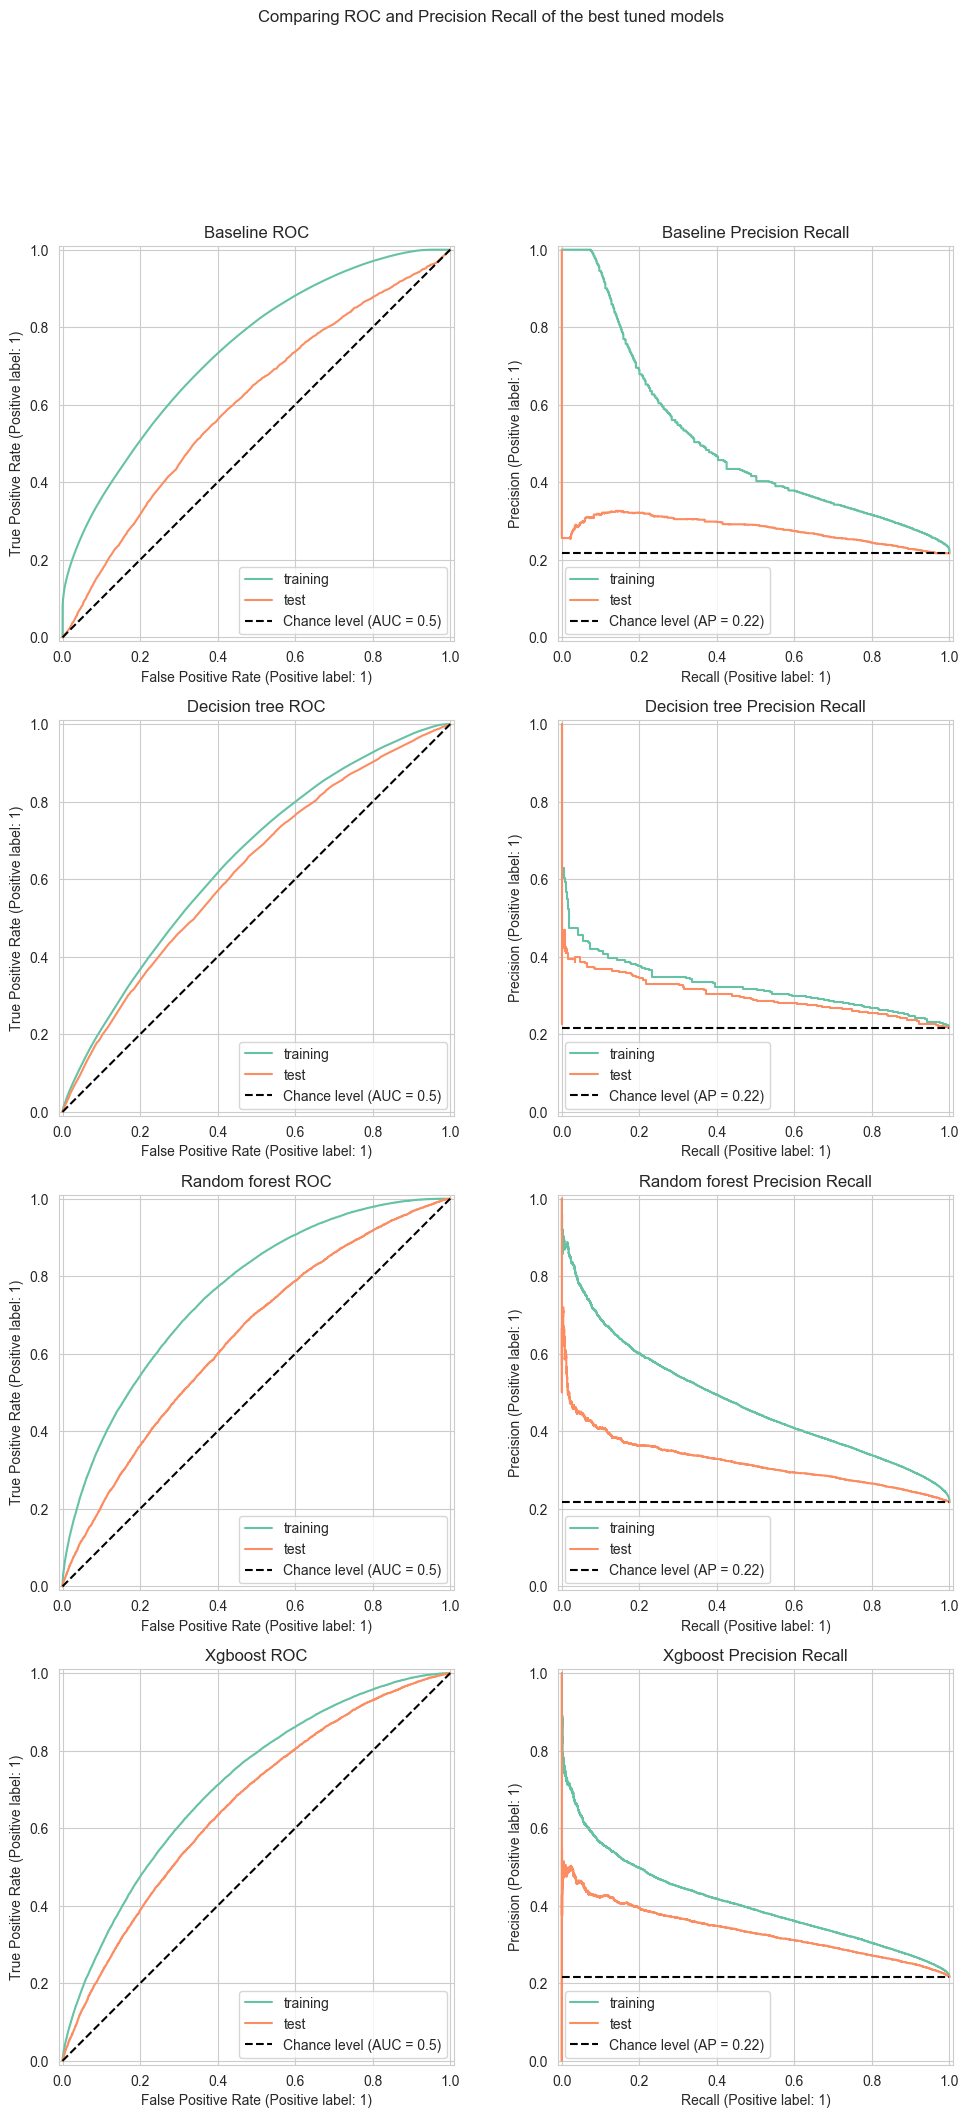

In [102]:
# https://matplotlib.org/stable/gallery/subplots_axes_and_figures/subplots_demo.html
# IDEA  yellowbrick.model_selection.learning_curve

fig, axs = plt.subplots( len(best_tuning.keys()) , 2, figsize=(30*cm, 15*cm * len(best_tuning.keys()) ))
fig.suptitle('Comparing ROC and Precision Recall of the best tuned models')

for row, (key, best_result) in enumerate(best_tuning.items()):
    # print(row, key, best_result)
    l, r = 0, 1
    left  = axs[l] if len(best_tuning.keys()) == 1 else axs[row, l]
    right = axs[r] if len(best_tuning.keys()) == 1 else axs[row, r]
    
    *_, model, vectorizer, fitter, predicter = best_result.values()
    fitter(model, vectorizer, df_full, y_full, df_test, y_test)

    RocCurveDisplay.from_estimator(model, df_full, y_full, ax=left, label='training')
    RocCurveDisplay.from_estimator(model, df_test, y_test, ax=left, label='test', plot_chance_level=True)
    left.set_title(f"{key.replace('_', ' ').capitalize()} ROC")
    
    PrecisionRecallDisplay.from_estimator(model, df_full, y_full, ax=right, label='training')
    PrecisionRecallDisplay.from_estimator(model, df_test, y_test, ax=right, label='test', plot_chance_level=True)
    right.set_title(f"{key.replace('_', ' ').capitalize()} Precision Recall")

del row, key, l, r, left, right, vectorizer, fitter, predicter
# Hide x labels and tick labels for top plots and y ticks for right plots
# for ax in axs.flat:
#     ax.label_outer()

Observations:

 - Although hyperparameter tuning was "brute force", the tuned Decision Tree is most successful in avoiding over- or under-fitting. That is, the results of both training and test datasets are most consistent of all the chosen options
 - Curiously, the not-tuned baseline (Decision Tree) model is out-performing the tuned models in both ROC and Precision/Recall, albeit least accurate.  There's probably skills / experience the author has yet to learn that unlocks this observation today, perhaps in the realms of feature engineering or model hyperparameter tuning
 - However, in both ROC and PrecisionRecall, the tuned XGBoost model performs best on the test dataset

Therefore, on balance, **the author chooses the XGBoost model** for continued model persistence and wrapping into an API.  It's a "lego block" that can easily be substituted as and when a better model is created.  This would be the Minimum Viable Product (MVP) approach, recognising that improvement is likely with data, experience, skills, and time altogether. It's no different to any software product.

In [103]:
best_tuning['xgboost']


{
    'eta': 0.3667,
    'scale_pos_weight': 2.0,
    'max_depth': 5.0,
    'n_estimators': 55.0,
    'f1': 0.729,
    'roc_auc': 0.571,
    'model': XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=50,
              enable_categorical=True, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.3667, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=55, n_jobs=-1,
              num_parallel_tree=None, random_state=42, ...),
    'vectorizer': None,
    'fitter': <function <lambda> at 0x000001A201697600>,
    'predicter': <fu

**NOTE**:  Please refer to `./train_and_persist.py` for continued model persistence into `./models/` 